# 📘 Probabilistic Time-Series Forecasting with RNNs, LSTMs and Transformers (DeepAR-style)

This notebook focuses on probabilistic autoregressive forecasting using real-world data.  
We compare three neural forecasting architectures:

- Vanilla RNN  
- LSTM  
- Transformer (autoregressive)

All experiments use the ETTh1 (Electricity Transformer Temperature – hourly) dataset.  
No synthetic or AR-generated data is used.

---

## 📡 Dataset: ETTh1 (Electricity Transformer Temperature)

ETTh1 contains two years of hourly measurements from an electricity transformer.  
In this notebook we:

- use OT (Oil Temperature) as the univariate target  
- optionally subsample the raw signal (e.g., 1 every 10 samples) to emphasize long-range temporal structure  
- extract many overlapping windows for training and testing  

The dataset exhibits clear daily and weekly seasonality, nonlinear effects, and long-range dependencies, making it a suitable benchmark for autoregressive models.

---

## 🎯 Objectives

1. **Load and preprocess ETTh1**  
   Standardize the OT series, optionally subsample it, and extract overlapping windows.

2. **Create a train/test split**  
   Models are trained on the first part of each window and evaluated on a held-out test set.

3. **Train probabilistic autoregressive models**  
   Each model predicts a Gaussian distribution at each time step:

   $$
   p(y_t \mid y_{1:t-1}) = \mathcal{N}(\mu_t, \sigma_t^2)
   $$

   where the network outputs:  
   - mean $\mu_t$  
   - standard deviation $\sigma_t$

4. **Autoregressive forecasting**  
   Models are trained using only the first $T_{\text{train}}$ time steps and then rolled out to reconstruct the full sequence.

5. **Evaluate reconstruction**  
   We compute the mean squared error (MSE) between full reconstructed sequences and ground truth, comparing RNN, LSTM and Transformer performance.

---

## 🧠 Why This Matters

Real time-series often display:

- long-range correlations  
- seasonality and periodicity  
- nonlinear behaviors  
- noise and uncertainty  

RNNs and LSTMs rely on sequential hidden states and may struggle with long forecasting horizons.  
Transformers, using self-attention, can directly attend to distant time steps and may better capture long-range dependencies.

This notebook provides a controlled comparison on real data to explore:

- how each architecture models temporal structure  
- how uncertainty propagates in autoregressive rollouts  
- whether Transformers offer measurable improvements for long-horizon reconstruction

---

## 🗂 Notebook Structure

1. Load and preprocess ETTh1  
2. Subsample and extract windows  
3. Train/test split  
4. Model definitions (RNN, LSTM, Transformer)  
5. Gaussian likelihood training  
6. Autoregressive forecasting  
7. MSE reconstruction evaluation  
8. Visual comparison  

---


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # Set to your desired GPU number

import torch
print(torch.cuda.device_count())  # Should now reflect only the visible GPUs

1


In [3]:
import torch
from torch import nn
from torch import optim
import numpy as np
import time
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'  #To get figures with high quality!


## 📡 ETTh1 Dataset: Electricity Transformer Temperature (Hourly)

The ETTh1 dataset contains two years of **hourly measurements** collected from an electricity transformer station.  
It is one of the standard benchmarks used in modern forecasting literature, especially in Transformer-based models.

The dataset includes operational and environmental variables such as:

- OT — Oil Temperature (target variable used in this notebook)  
- HUFL, HULL — High Use Load features  
- MUFL, MULL — Medium Use Load features  
- LUFL, LULL — Low Use Load features  

For the purposes of this notebook, we focus on a **univariate forecasting** version by selecting the OT signal as the target.

### Why OT?

Oil temperature is strongly influenced by:

- load conditions  
- ambient temperature  
- cyclic usage patterns over days and weeks  

As a result, OT exhibits **seasonality**, **long-range structure**, and **non-linear dynamics**, making it well suited for evaluating autoregressive forecasting models.

### Preprocessing Steps

In this notebook, we:

1. Load the hourly ETTh1 dataset (`ETTh1.csv`).  
2. Extract the OT column as a continuous univariate time series.  
3. Standardize the series (zero mean, unit variance).  
4. Optionally **subsample** the series (e.g., keeping 1 every 10 points) to emphasize long-range dependencies.  
5. Generate many overlapping windows to serve as training and testing samples.

These windows form the basis for training RNN, LSTM and Transformer models and evaluating their ability to reconstruct long-horizon dynamics in an autoregressive setting.

---


In [4]:
import numpy as np
import pandas as pd

# --------------------------------------------------------
# 1. Load ETTh1 and extract the OT (oil temperature) series
# --------------------------------------------------------

# Assumes ETTh1.csv is in the current working directory
df = pd.read_csv("ETTh1.csv")

# Use OT (oil temperature) as a univariate time series
series = df["OT"].values.astype(np.float32)

# Standardize the series (zero mean, unit variance)
mean = series.mean()
std = series.std()
series = (series - mean) / std

# --------------------------------------------------------
# 2. Subsample the raw series to emphasize long-range structure
# --------------------------------------------------------

subsample_factor = 10  # keep one every 10 samples
series_sub = series[::subsample_factor]   # subsampled series
T_total = len(series_sub)

print(f"Total length after subsampling: {T_total}")

# --------------------------------------------------------
# 3. Build overlapping input/target sequences
# --------------------------------------------------------
# We build N random windows of length T+1 from the subsampled series.
# For each window:
#   - X: first T samples
#   - Y: next T samples (one-step-ahead targets)

T = 200     # length of each sequence (after subsampling)
N = 5000    # number of sequences to sample

# Safety check: ensure that a window of length T+1 fits in the series
if T_total <= T + 1:
    raise ValueError(
        f"Not enough data after subsampling to create sequences of length {T+1}. "
        f"T_total = {T_total}"
    )

X_list, Y_list = [], []

for i in range(N):
    # Random starting index: window [start, start + T] must fit
    start = np.random.randint(0, T_total - (T + 1))

    # Extract a window of length T+1
    seq = series_sub[start : start + T + 1]

    # Inputs: first T points
    X_list.append(seq[:-1])

    # Targets: one-step-ahead values
    Y_list.append(seq[1:])

# Stack into arrays of shape (N, T)
X = np.stack(X_list, axis=0)
Y = np.stack(Y_list, axis=0)

print(f"X shape: {X.shape}, Y shape: {Y.shape}")

# --------------------------------------------------------
# 4. Train / Test split (over sequences)
# --------------------------------------------------------
# We split the set of sequences into train and test subsets.
# Each sequence is kept intact; we do not split along the time axis here.

test_ratio = 0.2
N_total = X.shape[0]
N_test = int(N_total * test_ratio)
N_train = N_total - N_test

# Shuffle indices so train/test are random
perm = np.random.permutation(N_total)
train_idx = perm[:N_train]
test_idx = perm[N_train:]

X_train = X[train_idx]
Y_train = Y[train_idx]
X_test = X[test_idx]
Y_test = Y[test_idx]

print("Train:", X_train.shape, Y_train.shape)
print("Test :", X_test.shape, Y_test.shape)

# --------------------------------------------------------
# 5. Context length for training (autoregressive models)
# --------------------------------------------------------
# Models will be trained to use only the first T_train time steps
# as conditioning context, and later we will forecast beyond T_train.

T_train = 100
print("Context length T_train:", T_train)
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)


Total length after subsampling: 1742
X shape: (5000, 200), Y shape: (5000, 200)
Train: (4000, 200) (4000, 200)
Test : (1000, 200) (1000, 200)
Context length T_train: 100
X_train: (4000, 200) Y_train: (4000, 200)


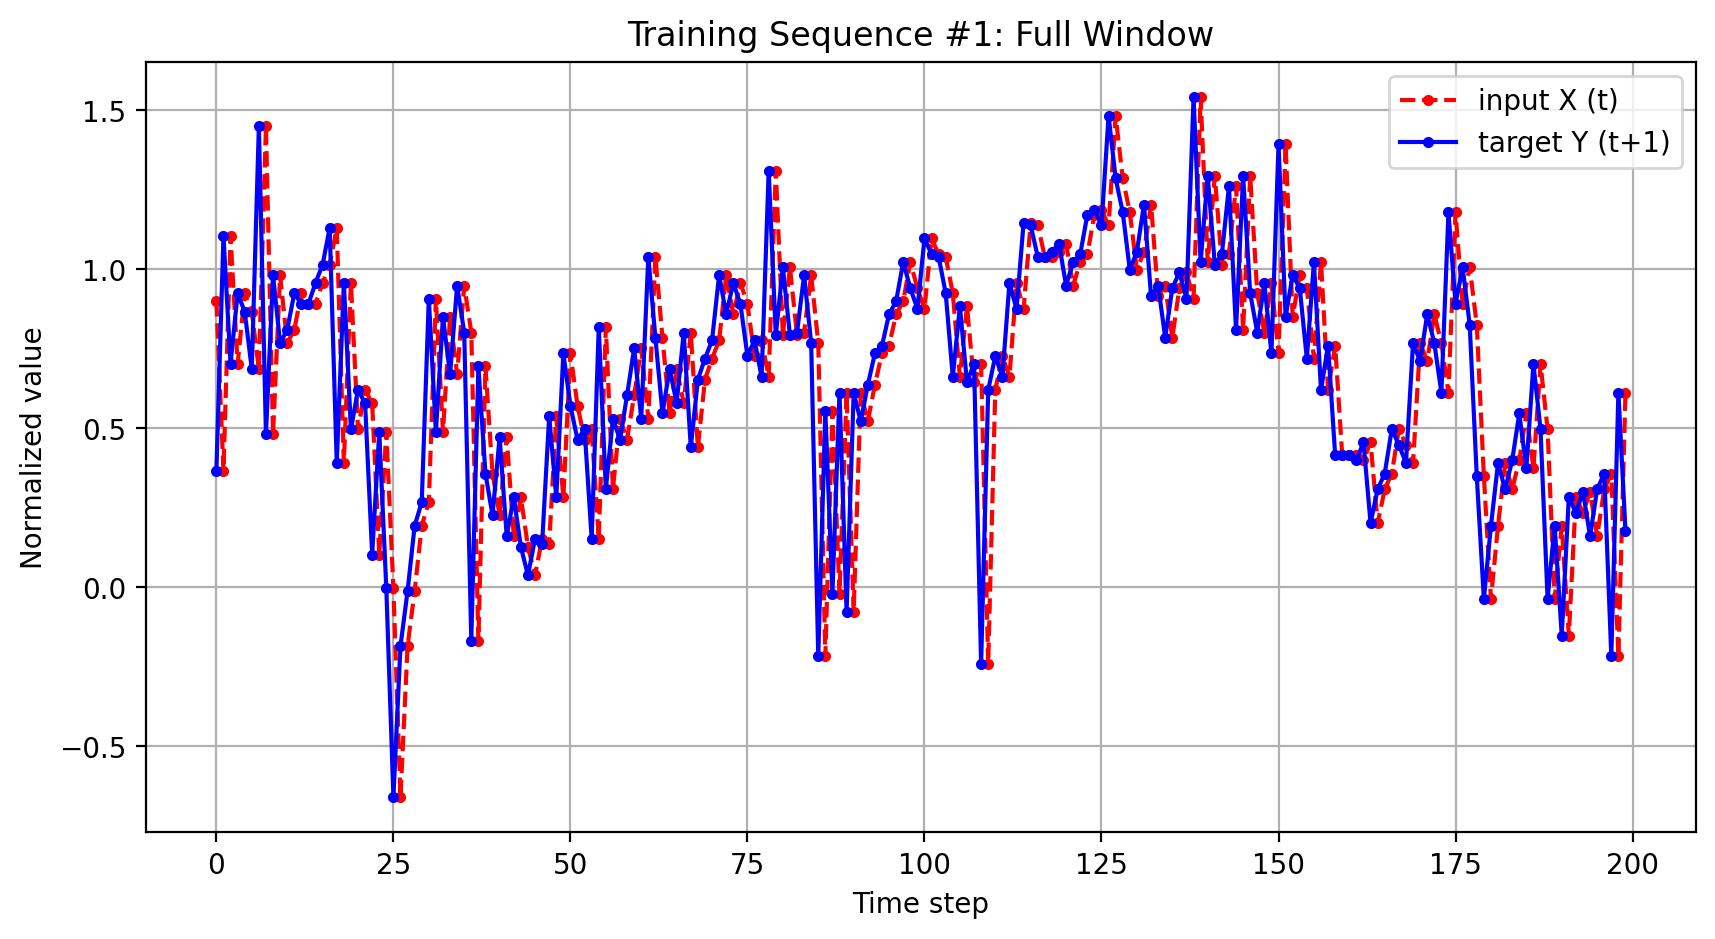

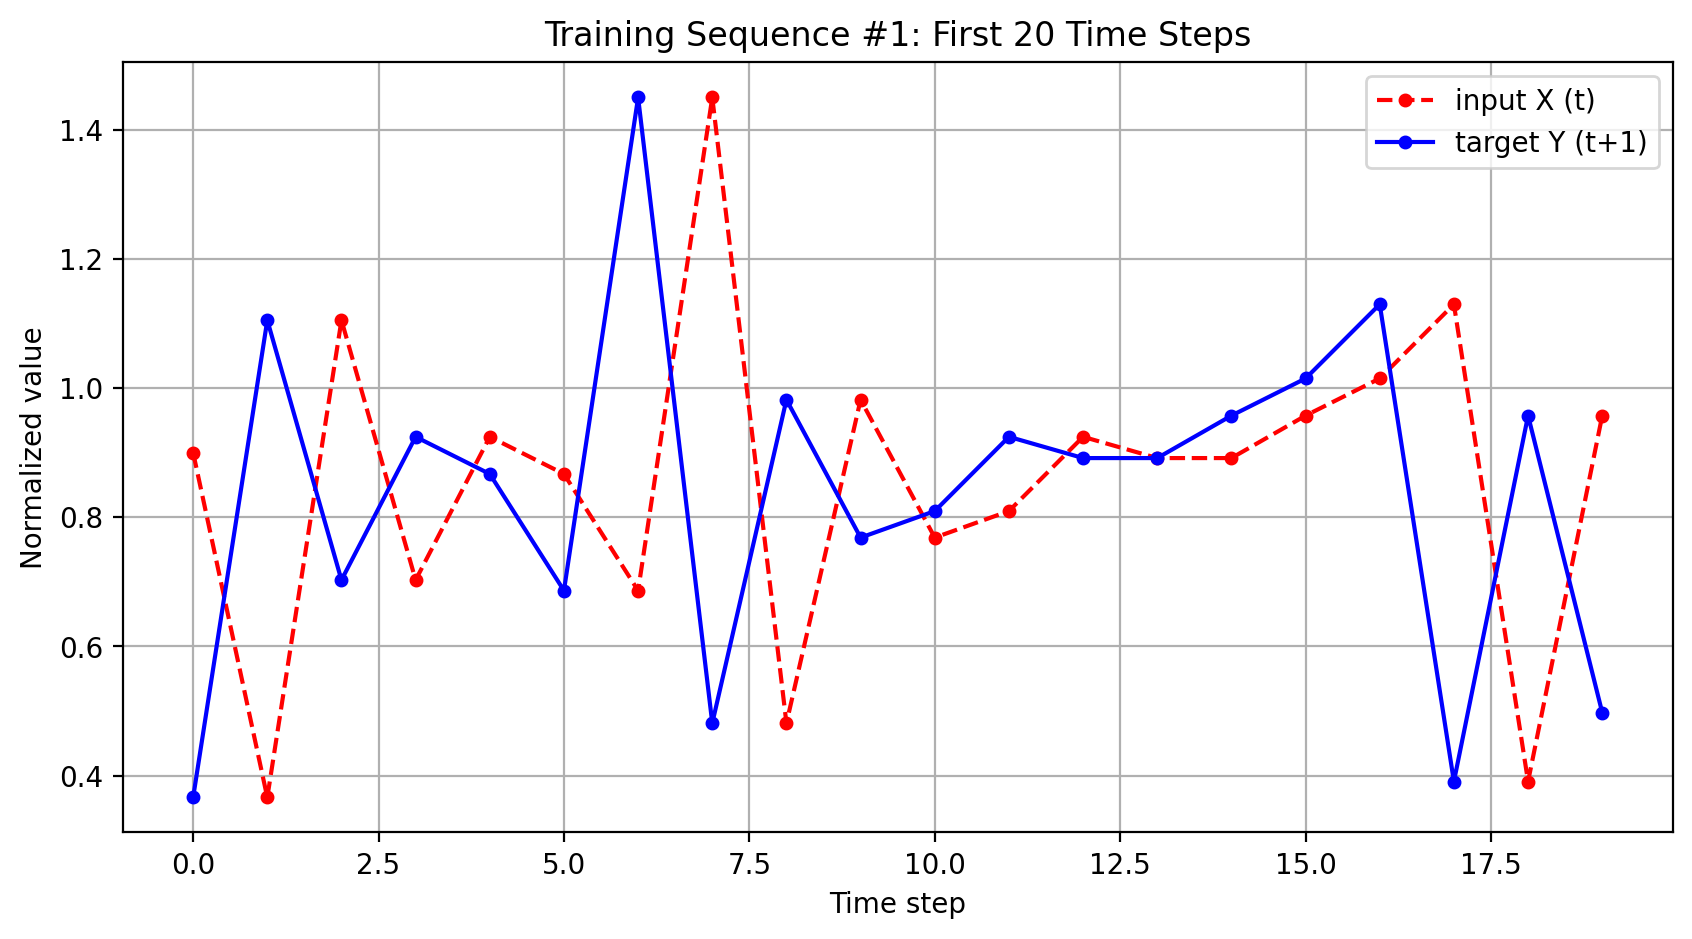

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# Plot a full training sequence (both X and Y)
# --------------------------------------------------------

signal_id = 1  # you can change the index to inspect other sequences

plt.figure(figsize=(10, 5))
plt.plot(np.arange(T), X_train[signal_id, :T], 'r.--', ms=6, label='input X (t)')
plt.plot(np.arange(T), Y_train[signal_id, :T], 'b.-', ms=6, label='target Y (t+1)')
plt.title(f"Training Sequence #{signal_id}: Full Window")
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# --------------------------------------------------------
# Zoom into the first 20 time steps
# --------------------------------------------------------

zoom = 20

plt.figure(figsize=(10, 5))
plt.plot(np.arange(zoom), X_train[signal_id, :zoom], 'r.--', ms=8, label='input X (t)')
plt.plot(np.arange(zoom), Y_train[signal_id, :zoom], 'b.-', ms=8, label='target Y (t+1)')
plt.title(f"Training Sequence #{signal_id}: First {zoom} Time Steps")
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend(loc='best')
plt.show()


## Part II. Building the RNN

Next, we build the RNN in PyTorch. We start with a basic RNN using `nn.RNN`.  
Its key parameters are:

- **input_size** – dimension of each input $x_t$ (1 for our univariate OT series)  
- **hidden_dim** – dimension of the hidden state $h_t$  
- **n_layers** – number of stacked recurrent layers  

Below is a schematic of a stacked (hierarchical) RNN:

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*sBfgsRRLyknLfca7.jpg" width="40%">

---

### RNN recurrence

According to the [PyTorch documentation](https://pytorch.org/docs/stable/nn.html#rnn),  
the hidden state is updated as:

$$
h_{t} = \tanh(W_x x_t + W_h h_{t-1} + b_h).
$$

`nn.RNN` produces the sequence of hidden states and the final hidden state for the last time step.

---

## Output layer: predicting a Gaussian distribution

Instead of directly predicting the next value, the model predicts the parameters of a **Gaussian distribution**:

$$
p(x_{t+1} \mid x_{0:t}) = \mathcal{N}(\mu_{t+1}, \sigma_{t+1}^2),
$$

where both:

- $\mu_{t+1}$ (mean), and  
- $\sigma_{t+1}$ (standard deviation)  

are produced from the hidden state $h_t$ through a small MLP.

We enforce positivity of the variance by mapping a raw output through a function such as `softplus`.

---

## Training objective: sampling + L2 regression

Our training objective is **not** maximum likelihood.  
Instead, we use a **sampling-based regression** approach:

1. From the predicted Gaussian parameters $(\mu_t, \sigma_t)$,  
   we **sample** a candidate next value:

   $$
   \hat{x}_t = \mu_t + \sigma_t \, \epsilon_t, \qquad \epsilon_t \sim \mathcal{N}(0,1).
   $$

2. We compute an **L2 loss** between the sampled next value and the ground-truth next value:

   $$
   \mathcal{L}_t = \| x_t - \hat{x}_t \|_2^2.
   $$

3. The final loss is the average over all time steps in the training window.

This method allows the model to:

- learn both the mean and variance dynamics,  
- inject stochasticity into the training process,  
- and behave as a **generative autoregressive model** during forecasting.

---

## Teacher forcing during training

We use **teacher forcing**:

- At each time step, the **true** previous value is fed into the RNN.
- The model predicts $(\mu_t, \sigma_t)$ from the hidden state.
- A sample $\hat{x}_t$ is drawn from the predicted Gaussian.
- Training minimizes the L2 difference between $\hat{x}_t$ and the true $x_t$.

This stabilizes gradients and prevents error accumulation inside the sequence.

---

## Autoregressive forecasting (inference)

During inference:

1. We feed the last observed value (the end of the context window).  
2. The model predicts $(\mu_t, \sigma_t)$ and samples $\hat{x}_t$.  
3. This $\hat{x}_t$ becomes the input for the next time step.  
4. The process is repeated to roll out a full forecast trajectory.

This procedure is identical for RNN, LSTM, and Transformer models, enabling a fair comparison.

---

### Tensor shapes for `nn.RNN`

PyTorch expects:

- Input tensor: `(seq_len, batch_size, input_size)`  
- Output tensor:  
  - `output`: `(seq_len, batch_size, hidden_dim)`  
  - `hidden`: `(n_layers, batch_size, hidden_dim)`

We reorganize tensors accordingly inside the model's `forward()` method.

The class below implements:

- the recurrent backbone (`nn.RNN`),
- the MLP producing mean and variance,
- sampling of the next value,
- L2 regression under teacher forcing,
- autoregressive forecasting.


In [6]:
class RNN(nn.Module):
    """
    Basic RNN-based autoregressive model that predicts:
        - mean_t    (Gaussian mean of x_t)
        - std_t     (Gaussian std of x_t)
        - sample_t  (sampled prediction x_t = mean_t + std_t * eps)

    Training minimizes L2 distance between sample_t and the true value.
    """

    def __init__(self, input_size, output_size, hidden_dim, n_layers, sigma):
        """
        input_size  : dimensionality of x_t (1 for univariate OT)
        output_size : number of outputs (2 = mean + variance)
        hidden_dim  : hidden state size h_t
        n_layers    : number of stacked RNN layers
        sigma       : base noise level (not used if std predicted directly)
        """
        super().__init__()

        self.input_size  = input_size
        self.output_size = output_size   # should be 2: (mean, variance)
        self.hidden_dim  = hidden_dim
        self.sigma       = sigma

        # ------------------------------------------------------------
        # RNN backbone
        # ------------------------------------------------------------
        # batch_first=True → input shape = (batch_size, seq_len, input_dim)
        # nonlinearity='relu' because default tanh is weaker for some tasks
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            nonlinearity='relu',
            batch_first=True
        )

        # ------------------------------------------------------------
        # MLP head predicting mean and variance from hidden states
        # ------------------------------------------------------------
        self.fc0  = nn.Linear(hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc1  = nn.Linear(hidden_dim, output_size)  # 2 outputs → [mean, raw_variance]

        # ------------------------------------------------------------
        # Device configuration
        # ------------------------------------------------------------
        USE_GPU = True
        self.device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")
        self.to(self.device)

    # ------------------------------------------------------------
    # Forward pass
    # ------------------------------------------------------------
    def forward(self, x, h0=None):
        """
        x  : input sequence of shape (batch_size, seq_length, input_size)
        h0 : optional initial hidden state,
             shape = (n_layers, batch_size, hidden_dim)

        Returns:
            media  : predicted means (N, T, 1)
            std    : predicted stddevs (N, T, 1)
            hidden : final hidden state (n_layers, N, hidden_dim)
            sample : sampled trajectory (N, T, 1)
        """

        batch_size = x.size(0)   # N
        seq_length = x.size(1)   # T

        # --------------------------------------------------------
        # Run RNN
        # --------------------------------------------------------
        # r_out: (N, T, hidden_dim)
        # hidden: (n_layers, N, hidden_dim)
        r_out, hidden = self.rnn(x, h0)

        # Flatten across time for the MLP:
        # r_out_flat: (N*T, hidden_dim)
        r_out_flat = r_out.reshape(-1, self.hidden_dim)

        # --------------------------------------------------------
        # Predict Gaussian parameters for each time step
        # --------------------------------------------------------
        aux = self.fc1(self.relu(self.fc0(r_out_flat)))

        # mean and raw std for all time steps (flattened)
        media = aux[:, 0]                                # (N*T,)
        std   = torch.nn.functional.softplus(aux[:, 1])  # ensure positivity

        # --------------------------------------------------------
        # Sample from the Gaussian: x_t = mean + std * eps
        # --------------------------------------------------------
        noise = torch.randn_like(media) * std
        sample = media + noise

        # --------------------------------------------------------
        # Reshape outputs back to (N, T, 1)
        # --------------------------------------------------------
        media  = media.reshape(batch_size, seq_length, 1)
        std    = std.reshape(batch_size, seq_length, 1)
        sample = sample.reshape(batch_size, seq_length, 1)

        return media, std, hidden, sample


We now instantiate the RNN class using `hidden_dim=32`, `n_layers=2` and `sigma=1`

In [7]:
my_rnn = RNN(input_size=1, output_size=2, hidden_dim=32, n_layers=2,sigma=1)

Using the `forward` method, we compare the predicted signal against the true value during the first 20 time steps for one of the signals. Keep in mind that the RNN parameters have not been trained...

Hidden state shape (h): torch.Size([2, 4000, 32])
Prediction shape (mean): torch.Size([4000, 200, 1])


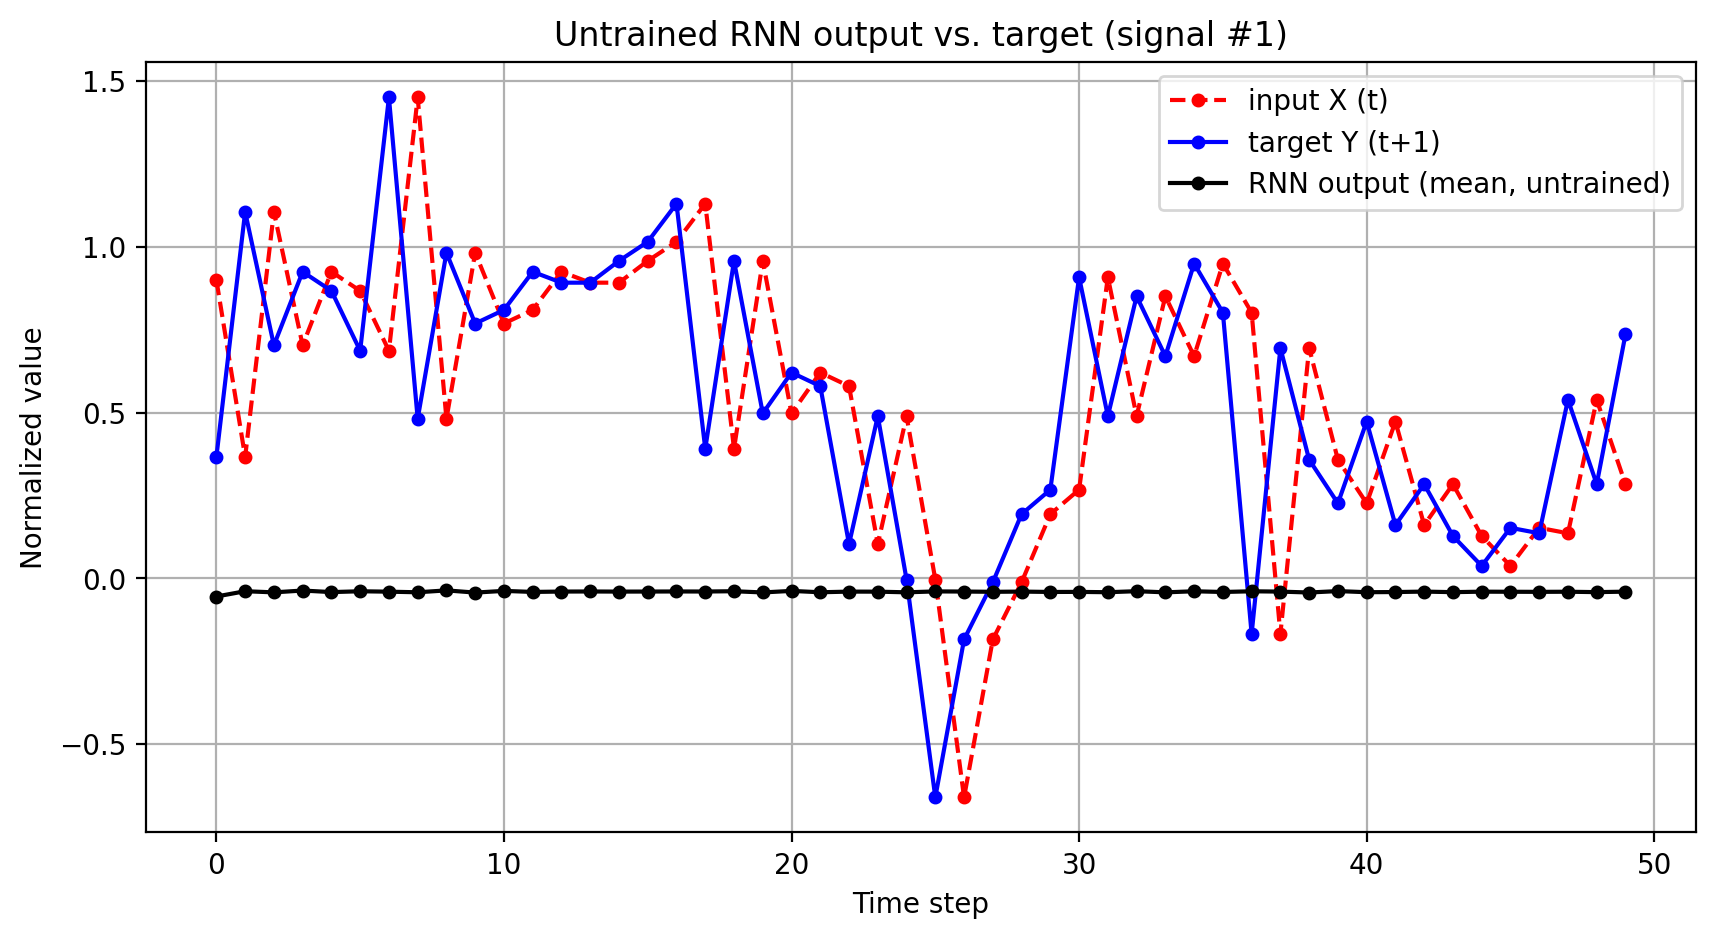

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 1. Prepare input tensor for the RNN
# --------------------------------------------------------
# X_train has shape (N_train, T), we add a feature dimension = 1
# Resulting shape: (N_train, T, 1)
X_in = torch.from_numpy(X_train).float().view(-1, T, 1)

# Move model to CPU (for this quick check)
my_rnn.device = torch.device("cpu")
my_rnn.to(my_rnn.device)

# Also move input to the same device as the model
X_in = X_in.to(my_rnn.device)

# --------------------------------------------------------
# 2. Forward pass (without training)
# --------------------------------------------------------
# mean  : (N_train, T, 1)
# std   : (N_train, T, 1)
# h     : final hidden state, shape (n_layers, N_train, hidden_dim)
# sample: sampled trajectory, shape (N_train, T, 1)
mean, std, h, sample = my_rnn.forward(X_in)

print("Hidden state shape (h):", h.shape)
print("Prediction shape (mean):", mean.shape)

# Convert mean prediction to NumPy for plotting
# output_no_train: (N_train, T)
output_no_train = mean.detach().cpu().numpy().reshape(N_train, -1)

# --------------------------------------------------------
# 3. Plot one example sequence before training
# --------------------------------------------------------
t0 = 0       # initial time index
tf = 50      # final time index (exclusive)
signal = 1   # index of the signal to visualize

plt.figure(figsize=(10, 5))
plt.plot(np.arange(t0, tf), X_train[signal, t0:tf], 'r.--', ms=8, label='input X (t)')
plt.plot(np.arange(t0, tf), Y_train[signal, t0:tf], 'b.-',  ms=8, label='target Y (t+1)')
plt.plot(np.arange(t0, tf), output_no_train[signal, t0:tf], 'k.-', ms=8, label='RNN output (mean, untrained)')
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.title(f"Untrained RNN output vs. target (signal #{signal})")
plt.grid(True)
plt.legend(loc='best')
plt.show()


### RNN\_extended: training the model

We now extend the basic `RNN` class with a small wrapper that takes care of **training**.  
This extended class will:

- wrap the base model
- define an optimizer and learning rate
- run the training loop for a fixed number of iterations
- keep track of the loss during training

In this notebook, we keep the training setup intentionally simple:

- **Full-batch training**:  
  On each iteration we use **all training signals at once**.  
  If we denote:
  - $N$ = number of training sequences
  - $T_{\text{train}}$ = context length used for training
  then the input tensor has shape $(N, T_{\text{train}}, 1)$.

  We do *not* use mini-batches here (even though that would be more scalable in practice).

- **Loss function**:  
  At each time step the RNN outputs the parameters $(\mu_t, \sigma_t)$ of a Gaussian,  
  from which we sample a candidate prediction
  $$
  \hat{x}_t = \mu_t + \sigma_t \, \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0,1).
  $$
  The training objective is the mean squared error (L2 loss) between the sampled prediction and the ground-truth value:
  $$
  \mathcal{L} = \frac{1}{N T_{\text{train}}} \sum_{n=1}^N \sum_{t=1}^{T_{\text{train}}} \bigl(\hat{x}^{(n)}_t - x^{(n)}_t\bigr)^2.
  $$

- **Optimizer**:  
  We typically use Adam with a fixed learning rate (e.g., `lr=0.01`), which works well for this kind of model.

- **Gradient clipping**:  
  A key practical issue with recurrent networks is the possibility of **exploding gradients**:  
  when backpropagating through long sequences, the repeated application of Jacobians can lead to extremely large gradient norms, which destabilize training.

  To mitigate this, after calling `loss.backward()` we clip the gradient norm of all parameters:
  ```python
  torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=2.0)


In [9]:
class RNN_extended(RNN):
    """
    Extension of the base RNN model that adds:
        - optimizer
        - training loop
        - Gaussian negative log-likelihood loss
        - gradient clipping
        - loss tracking
    """

    def __init__(self, num_data_train, num_iter, sequence_length,
                 input_size, output_size, hidden_dim, n_layers, sigma, lr=0.001):
        """
        num_data_train : number of training sequences (N)
        num_iter       : number of optimization iterations
        sequence_length: training window length (T_train)
        input_size     : dimension of input features (1)
        output_size    : 2 (mean + variance)
        hidden_dim     : RNN hidden size
        n_layers       : number of stacked recurrent layers
        sigma          : minimum noise level (unused, but kept for consistency)
        lr             : learning rate for Adam
        """

        # Initialize the parent RNN class
        super().__init__(input_size, output_size, hidden_dim, n_layers, sigma)

        self.sequence_length = sequence_length
        self.num_train = num_data_train
        self.lr = lr
        self.num_iter = num_iter

        # Adam optimizer
        self.optim = optim.Adam(self.parameters(), lr=self.lr)

        # Storage for monitoring training progress
        self.loss_during_training = []

        # Enable autograd anomaly detection (useful but slower)
        torch.autograd.set_detect_anomaly(True)

    # ------------------------------------------------------------
    # Gaussian Negative Log Likelihood (per sample)
    # ------------------------------------------------------------
    def gaussian_nll(self, y, mean, std):
        """
        Computes the Gaussian negative log-likelihood:
            -log N(y | mean, std^2)

        y     : ground-truth values
        mean  : predicted Gaussian means
        std   : predicted Gaussian stds (softplus ensures positivity)
        """
        eps = 1e-6  # numerical stability
        std = std + eps
        var = std ** 2

        # Standard Gaussian NLL
        log_prob = -0.5 * (torch.log(2 * torch.pi * var) + ((y - mean) ** 2) / var)

        return -log_prob.mean()   # return mean NLL

    # ------------------------------------------------------------
    # TRAINING LOOP
    # ------------------------------------------------------------
    def trainloop(self, x, y):
        """
        Main training loop (full-batch training).
        x : training inputs   (N_train, sequence_length)
        y : training targets  (N_train, sequence_length)
        """

        # Convert to tensors and move to model's device
        x = torch.tensor(x, dtype=torch.float32).view(
            self.num_train, self.sequence_length, int(self.output_size / 2)
        ).to(self.device)

        y = torch.tensor(y, dtype=torch.float32).view(
            self.num_train, self.sequence_length, int(self.output_size / 2)
        ).to(self.device)

        # Optimization loop
        for e in range(int(self.num_iter)):

            self.optim.zero_grad()

            # Forward pass: mean, std, hidden_state, sample
            mean, std, hid, out = self.forward(x)

            # Compute Gaussian NLL
            loss = self.gaussian_nll(y, mean, std)

            # Backprop
            loss.backward()

            # Gradient clipping (RNNs can suffer exploding gradients)
            nn.utils.clip_grad_norm_(self.parameters(), max_norm=2.0)

            # Parameter update
            self.optim.step()

            # Record normalized loss
            self.loss_during_training.append(loss.item())

            # Print progress every 50 iterations
            if e % 50 == 0:
                print(f"Iteration {e}, Training loss: {loss.item():.6f}")


We now instantiate the `RNN_extended` class with `hidden_dim=32`, `n_layers=2` and `sigma=0.5`, using **only the first 100 time steps of each signal**, train the RNN

In [10]:
my_rnn = RNN_extended(num_data_train=X_train.shape[0],num_iter=250,sequence_length=T_train,
                     input_size=1,output_size=2,hidden_dim=32,n_layers=1,sigma=0.5,lr=0.005)

In [11]:
my_rnn.trainloop(X_train[:,:T_train],Y_train[:,:T_train])

Iteration 0, Training loss: 1.411073
Iteration 50, Training loss: 0.178986
Iteration 100, Training loss: 0.206585
Iteration 150, Training loss: 0.128451
Iteration 200, Training loss: 0.131418


Let's plot the cost function over time...


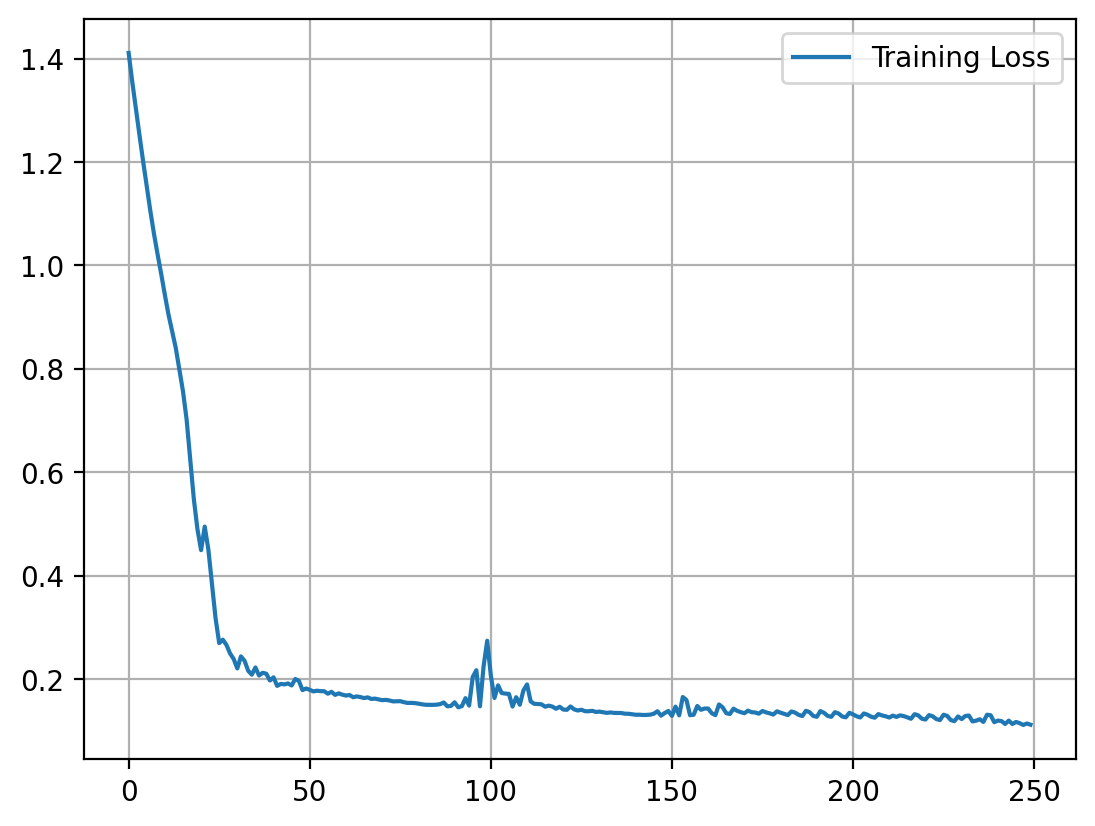

In [12]:
plt.plot(my_rnn.loss_during_training,label='Training Loss')
plt.grid()
plt.legend()

## Part IV. One-step-ahead Evaluation on the Test Set

Before evaluating the model autoregressively for long-horizon forecasting, it is useful to
evaluate how well it performs at the simplest possible task:

### One-step-ahead prediction

Given the test input window  
$x_0, x_1, \dots, x_{t-1}$  
the model predicts the Gaussian parameters $(\mu_t, \sigma_t)$ corresponding to the next value $x_t$.

In this block:

1. We run the trained RNN on the test set for the first $T_{\text{test}}$ time steps.  
2. We extract the predicted mean and standard deviation for every test sequence.  
3. We visualize one example test signal, showing  
   - the ground-truth target  
   - the predicted mean  
   - a confidence band based on $\pm 2\sigma$  
4. We compute the one-step-ahead MSE:

$$
\text{MSE} \;=\;
\frac{1}{N_{\text{test}} \, T_{\text{test}}}
\sum_{n=1}^{N_{\text{test}}}
\sum_{t=1}^{T_{\text{test}}}
\left(\mu_t^{(n)} - x_t^{(n)}\right)^2.
$$

This metric measures how accurate the model is when predicting only the next value, without any autoregressive accumulation of errors.

A low one-step-ahead MSE indicates that the model learns the short-term dynamics well.  
We will later compare this metric between the RNN, LSTM, and Transformer models.


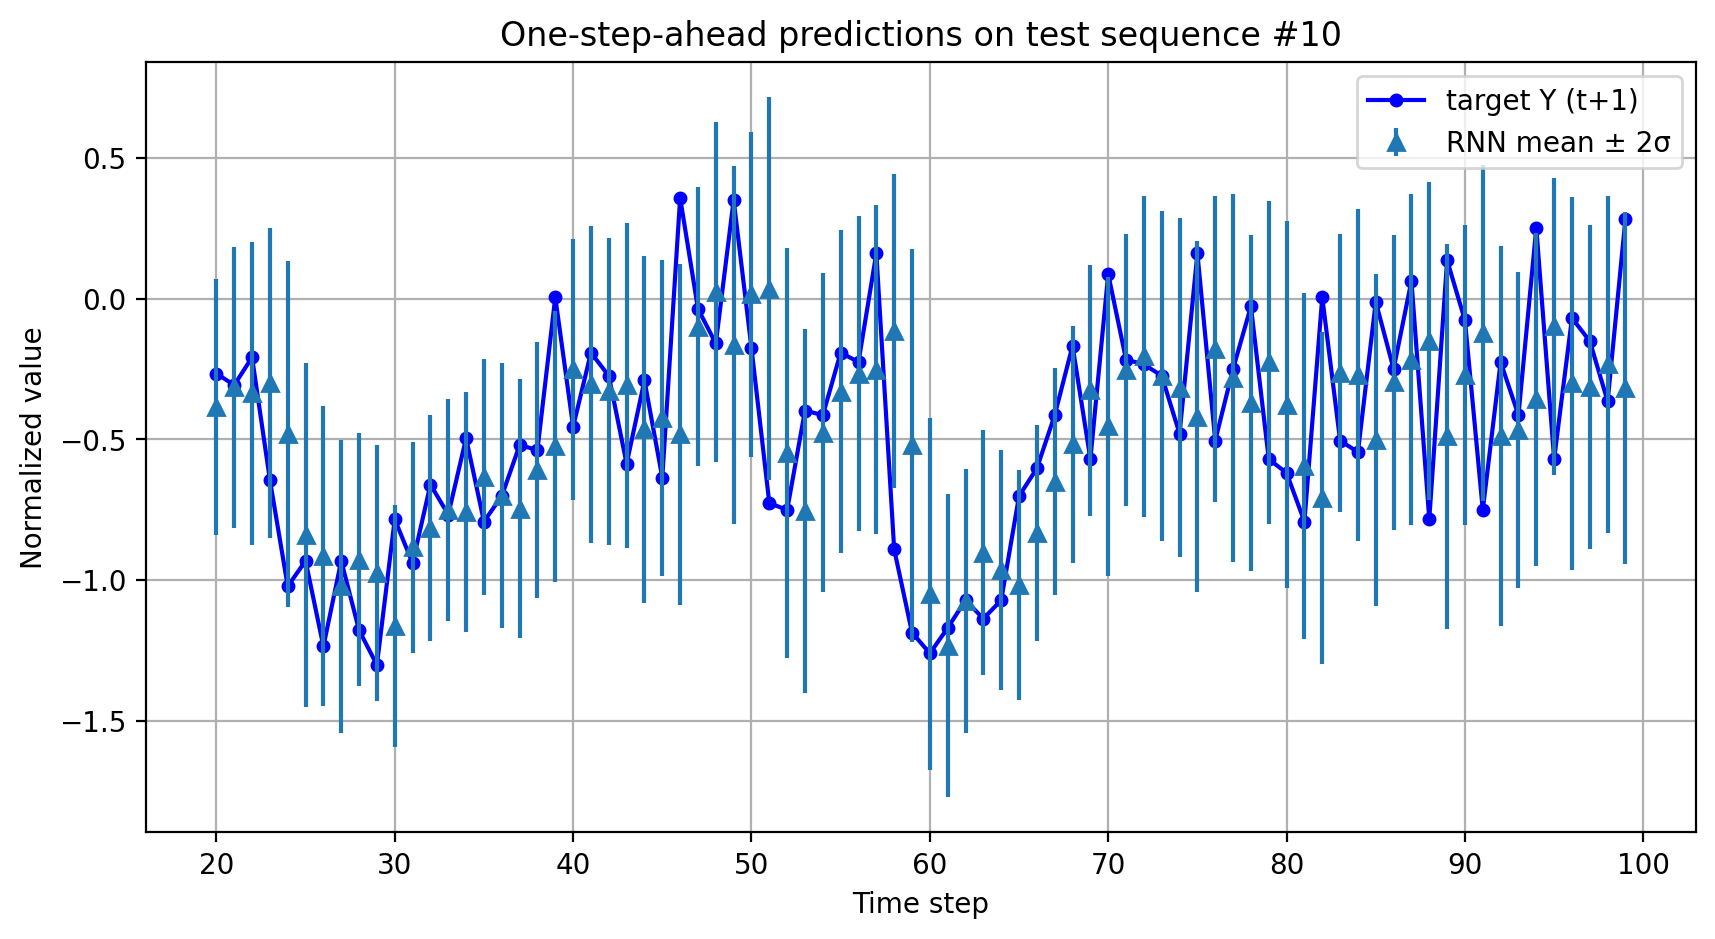

Test one-step-ahead MSE: 0.079916


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 1. Move model to CPU for evaluation on the test set
# --------------------------------------------------------
my_rnn.device = torch.device("cpu")
my_rnn.to(my_rnn.device)
my_rnn.eval()   # evaluation mode (disables dropout, etc. if any)

# --------------------------------------------------------
# 2. One-step-ahead prediction on the test set (up to T_test)
# --------------------------------------------------------
T_test = 100  # number of time steps for evaluation

# X_test has shape (N_test, T), we only take the first T_test steps
# and add a feature dimension -> (N_test, T_test, 1)
X_in = torch.from_numpy(X_test[:, :T_test]).float().view(N_test, T_test, 1).to(my_rnn.device)

# Forward pass through the RNN
# mean : (N_test, T_test, 1)
# std  : (N_test, T_test, 1)
# h    : final hidden state (n_layers, N_test, hidden_dim)
# sample: sampled trajectory (N_test, T_test, 1)
with torch.no_grad():
    mean, std, h, sample = my_rnn.forward(X_in)

# Convert to NumPy for plotting and MSE computation
mean_rnn = mean.detach().cpu().numpy().reshape(N_test, -1)   # (N_test, T_test)
std_rnn  = std.detach().cpu().numpy().reshape(N_test, -1)    # (N_test, T_test)

# --------------------------------------------------------
# 3. Plot one example test sequence with predictive mean + 2σ band
# --------------------------------------------------------
t0 = 20        # initial time index to plot
tf = T_test    # final time index (exclusive)
signal = 10    # index of the test signal to visualize (0 ≤ signal < N_test)

plt.figure(figsize=(10, 5))

# Ground-truth target (one-step ahead)
plt.plot(
    np.arange(t0, tf),
    Y_test[signal, t0:tf],
    'b.-',
    ms=8,
    label='target Y (t+1)'
)

# Predicted mean with 2*std error bars (approx 95% confidence)
plt.errorbar(
    np.arange(t0, tf),
    mean_rnn[signal, t0:tf],
    2 * std_rnn[signal, t0:tf],
    linestyle='None',
    marker='^',
    label='RNN mean ± 2σ'
)

plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.title(f"One-step-ahead predictions on test sequence #{signal}")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# --------------------------------------------------------
# 4. Compute global one-step-ahead MSE on the test set
# --------------------------------------------------------
# MSE averaged over all test sequences and all T_test time steps
mse_test = np.mean((mean_rnn - Y_test[:, :T_test]) ** 2)
print(f"Test one-step-ahead MSE: {mse_test:.6f}")


## Part V. Autoregressive Forecasting Beyond the Context Window

Up to this point, we have evaluated the RNN on a **one-step-ahead** prediction task, where
the model always receives the true previous value (teacher forcing).  
This allows us to measure how well the model captures *local* dynamics.

However, in real forecasting scenarios we must roll the model forward **without access to ground truth**.
This is the more challenging **autoregressive forecasting** setting:

1. We provide the model with the first $T_{\text{test}}$ observations of each test sequence.
2. At each subsequent step, the model:
   - predicts $(\mu_t, \sigma_t)$ from its hidden state,
   - samples $\hat{x}_t = \mu_t + \sigma_t \epsilon_t$ where $\epsilon_t \sim \mathcal{N}(0,1)$,
   - and uses this sampled value as the next input.
3. This process is repeated for the remaining $T - T_{\text{test}}$ steps.

Thus the model must **bootstrap its own predictions** and propagate uncertainty through time.

We then:

- concatenate the predicted segment with the initial $T_{\text{test}}$ steps,
- plot the reconstructed trajectory against the ground truth,
- and compute the **forecasting MSE**, defined as

$$
\text{MSE}_{\text{forecast}} =
\frac{1}{N_{\text{test}} (T - T_{\text{test}})}
\sum_{n=1}^{N_{\text{test}}}
\sum_{t=T_{\text{test}}}^{T-1}
\left( \hat{x}_t^{(n)} - x_t^{(n)} \right)^2.
$$

This metric evaluates how well the model performs when it must generate **its own future**,  
instead of relying on the ground truth at each step.

In the next code block, we implement this procedure and visualize the reconstruction of a test sequence.


Effective forecasting horizon: 20 steps


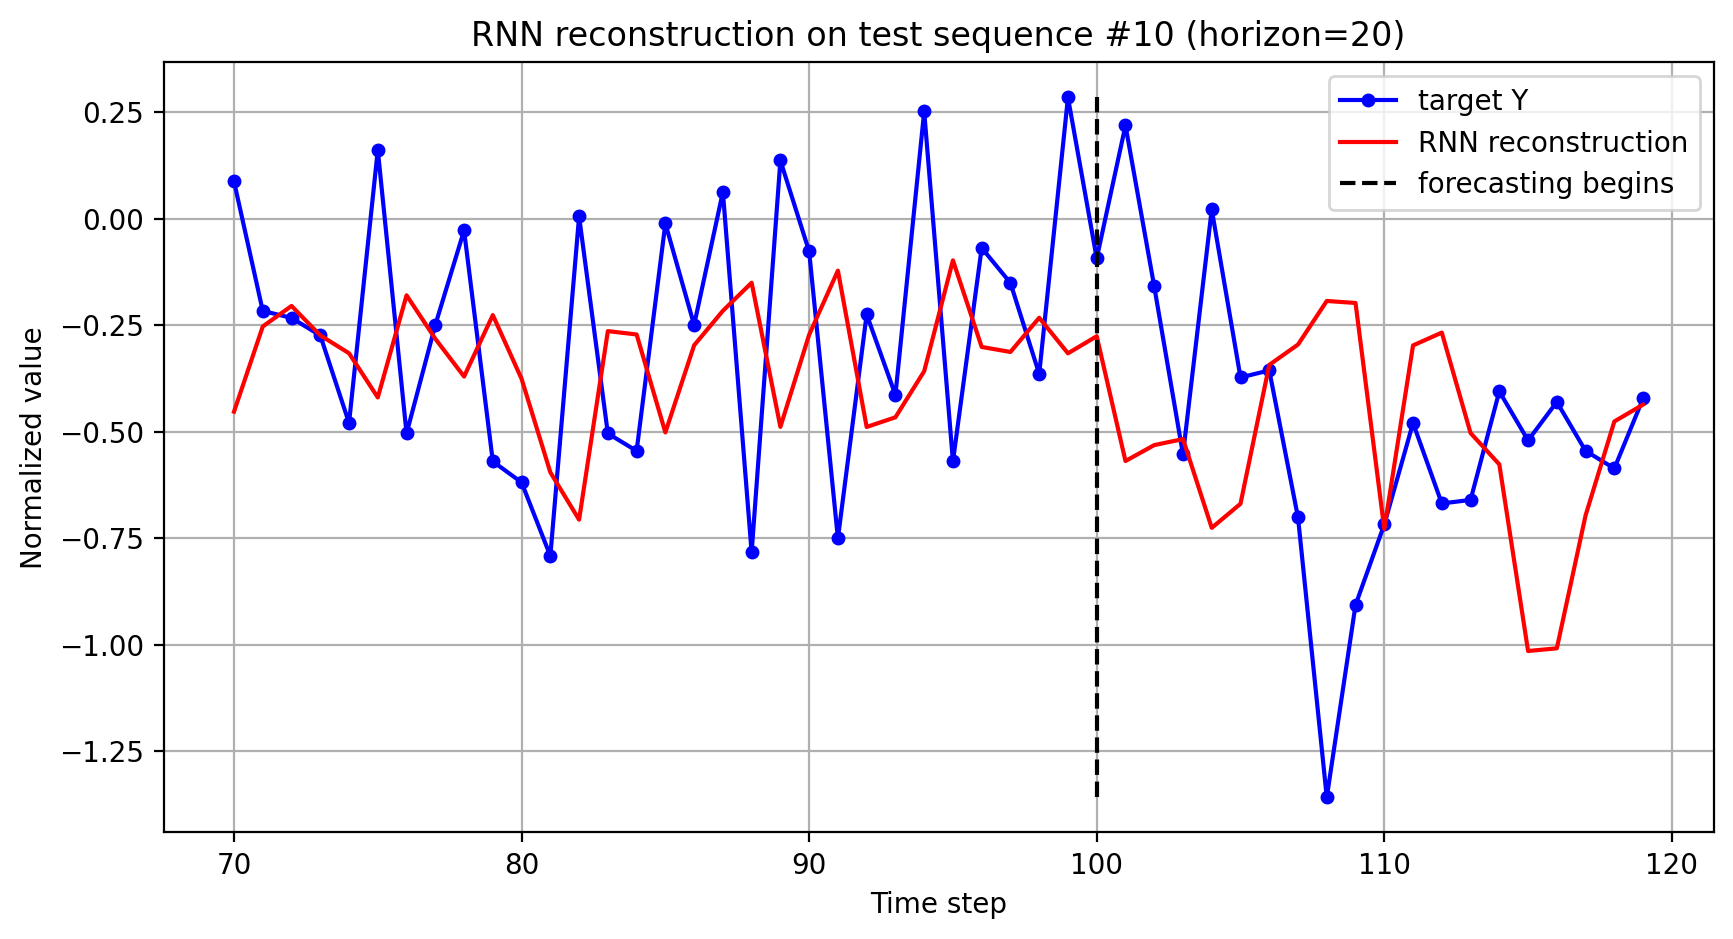

Test forecasting MSE (T_test → T_test + 20): 0.451069


In [15]:
# --------------------------------------------------------
# 0. Set forecasting horizon
# --------------------------------------------------------
H_forecasting = 20  # number of steps to forecast beyond T_test

# Make sure we don't step beyond sequence length T
H_eff = min(H_forecasting, T - T_test)

print(f"Effective forecasting horizon: {H_eff} steps")

# --------------------------------------------------------
# 1. Autoregressive forecasting on the test set
# --------------------------------------------------------
# At this point we have:
#   - mean_rnn : one-step-ahead means for the first T_test steps (N_test, T_test)
#   - std_rnn  : corresponding stds                        (N_test, T_test)
#   - h        : final hidden state from the test run
#   - sample   : sampled trajectory for the first T_test steps (N_test, T_test, 1)
#
# We now:
#   - take the last sampled point at time T_test - 1
#   - roll the RNN forward autoregressively to generate the next H_eff steps

# Last sampled point for each test sequence at time T_test - 1
# sample has shape (N_test, T_test, 1)
current_input = sample[:, -1, :].view(N_test, 1, 1)  # shape: (N_test, 1, 1)

# Last hidden state from the previous forward pass (will be updated at each step)
current_state = h

# Buffer to store forecasted points beyond T_test, up to horizon H_eff
forecast_rnn = np.zeros((N_test, H_eff))

# Switch to eval mode and no-grad for forecasting
my_rnn.eval()

for t in range(H_eff):
    # Iterative autoregressive sampling:
    #   - input: current_input (N_test, 1, 1)
    #   - hidden state: current_state
    #   - output sample: new current_input
    with torch.no_grad():
        mean_step, std_step, current_state, current_input = my_rnn.forward(current_input, current_state)

    # current_input has shape (N_test, 1, 1) → flatten to (N_test,)
    forecast_rnn[:, t] = current_input.detach().cpu().numpy().reshape(-1)

# --------------------------------------------------------
# 2. Concatenate context and forecast to get reconstruction up to T_test + H_eff
# --------------------------------------------------------
# mean_rnn: predictions for first T_test steps            (N_test, T_test)
# forecast_rnn: predictions for steps [T_test, T_test+H_eff) (N_test, H_eff)
final_rnn_reconstruct = np.hstack([mean_rnn, forecast_rnn])  # (N_test, T_test + H_eff)

# --------------------------------------------------------
# 3. Plot original vs reconstructed signal for one test sequence
# --------------------------------------------------------
t0 = max(0, T_test - 30)                 # start a bit before T_test
tfinal = T_test + H_eff                  # end at last forecasted point
signal = 10                              # index of the test signal to visualize

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(t0, tfinal),
    Y_test[signal, t0:tfinal].reshape(-1),
    'b.-',
    ms=8,
    label='target Y'
)
plt.plot(
    np.arange(t0, tfinal),
    final_rnn_reconstruct[signal, t0:tfinal],
    'r-',
    label='RNN reconstruction'
)

# Vertical line where autoregressive forecasting begins: at T_test
plt.plot(
    [T_test, T_test],
    [np.min(Y_test[signal, t0:tfinal]), np.max(Y_test[signal, t0:tfinal])],
    'k--',
    label='forecasting begins'
)

plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.title(f"RNN reconstruction on test sequence #{signal} (horizon={H_eff})")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# --------------------------------------------------------
# 4. Compute test forecasting MSE only over the horizon [T_test, T_test + H_eff)
# --------------------------------------------------------
Y_test_horizon = Y_test[:, T_test:T_test + H_eff]          # (N_test, H_eff)

mse_test_for = np.mean((forecast_rnn - Y_test_horizon) ** 2)
print(f"Test forecasting MSE (T_test → T_test + {H_eff}): {mse_test_for:.6f}")


## Part III. LSTMs

We now extend our study to **Long Short-Term Memory networks (LSTMs)**.  
LSTMs were specifically designed to address the limitations of vanilla RNNs, in particular the problems of **vanishing** and **exploding** gradients when learning long-term dependencies.

An LSTM cell maintains two internal states:

- the **hidden state** $h_t$ (similar to a standard RNN), and
- the **cell state** $c_t$, which acts as an explicit memory buffer.

Through a set of gated mechanisms (input, forget, and output gates), the LSTM decides which information to keep, which to discard, and how much of the past should influence future predictions. This architecture makes LSTMs far more effective than vanilla RNNs on data with long-range structure, such as the subsampled ETTh1 series we use in this notebook.

---

### Architecture and PyTorch implementation

PyTorch provides an optimized implementation of LSTMs via `nn.LSTM`.  
Its API is almost identical to `nn.RNN`:

- `input_size`  : dimension of each input $x_t$ (1 in our case)  
- `hidden_size` : dimensionality of the LSTM hidden and cell state  
- `num_layers`  : number of stacked LSTM layers  
- `batch_first` : expects inputs of shape `(batch, seq, features)` when `True`  

A key difference is that LSTMs return **two** final states:

- the final hidden state $h_T$  
- the final cell state $c_T$

Stacking multiple LSTM layers (`num_layers > 1`) allows the network to extract hierarchical temporal representations.  
In addition, PyTorch allows automatic **dropout between LSTM layers** using the `dropout=prob` argument:

```python
self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                    dropout=drop_prob, batch_first=True)


In [16]:
class LSTM(nn.Module):
    """
    LSTM-based autoregressive probabilistic model.

    Given an input sequence x of shape (N, T, 1), the model:
        1. passes it through an LSTM,
        2. maps each hidden state to (mean_t, std_t),
        3. samples x_t ~ N(mean_t, std_t^2).

    Returns:
        media  : predicted means      (N, T, 1)
        std    : predicted stds       (N, T, 1)
        hidden : final (h, c) states  (tuple of two tensors)
        sample : sampled predictions  (N, T, 1)
    """

    def __init__(self, input_size, output_size, hidden_dim, n_layers, sigma, drop_prob):
        """
        input_size  : dimension of input x_t      (1 for univariate)
        output_size : 2 (mean and variance)
        hidden_dim  : hidden state dimension
        n_layers    : number of stacked LSTM layers
        sigma       : base noise level (unused if std predicted)
        drop_prob   : dropout between stacked LSTM layers
        """
        super().__init__()

        self.hidden_dim  = hidden_dim
        self.input_size  = input_size
        self.output_size = output_size
        self.sigma       = sigma

        # ------------------------------------------------------------
        # LSTM backbone
        # ------------------------------------------------------------
        # batch_first=True → input expected as (batch, seq, features)
        # dropout applies *between* layers, not within the recurrent loop
        self.lstm = nn.LSTM(
            input_size,
            hidden_dim,
            n_layers,
            dropout=drop_prob if n_layers > 1 else 0.0,
            batch_first=True
        )

        # ------------------------------------------------------------
        # Output MLP: hidden_dim -> hidden_dim -> (mean, log_std)
        # ------------------------------------------------------------
        self.fc0  = nn.Linear(hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc1  = nn.Linear(hidden_dim, output_size)  # output: [mean, raw_std]

        # ------------------------------------------------------------
        # Device configuration
        # ------------------------------------------------------------
        USE_GPU = True
        self.device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")
        self.to(self.device)

    # ------------------------------------------------------------
    # Forward pass through the LSTM
    # ------------------------------------------------------------
    def forward(self, x, h0=None, valid=False):
        """
        x  : input sequence  (N, T, 1)
        h0 : optional initial state tuple (h0, c0)
             - h0: (n_layers, N, hidden_dim)
             - c0: (n_layers, N, hidden_dim)
        valid : True for evaluation mode (dropout disabled)

        Returns mean, std, hidden_state, and sampled trajectory.
        """

        batch_size  = x.size(0)   # N
        seq_length  = x.size(1)   # T

        # Switch between training and evaluation mode
        self.eval() if valid else self.train()

        # --------------------------------------------------------
        # LSTM processing
        # --------------------------------------------------------
        # r_out: (N, T, hidden_dim)
        # hidden = (h_T, c_T):
        #    h_T: (n_layers, N, hidden_dim)
        #    c_T: (n_layers, N, hidden_dim)
        r_out, hidden = self.lstm(x, h0)

        # Flatten for the MLP: (N*T, hidden_dim)
        r_out = r_out.reshape(-1, self.hidden_dim)

        # --------------------------------------------------------
        # Predict Gaussian parameters
        # --------------------------------------------------------
        aux = self.fc1(self.relu(self.fc0(r_out)))

        # Means (flattened)
        media = aux[:, 0]                # shape: (N*T,)
        # Std via softplus for positivity
        std   = torch.nn.functional.softplus(aux[:, 1])

        # --------------------------------------------------------
        # Sample from Gaussian: x_t ~ N(mean, std^2)
        # --------------------------------------------------------
        noise = torch.randn_like(media) * std
        sample = media + noise

        # --------------------------------------------------------
        # Reshape back to (N, T, 1)
        # --------------------------------------------------------
        media  = media.reshape(batch_size, seq_length, 1)
        std    = std.reshape(batch_size, seq_length, 1)
        sample = sample.reshape(batch_size, seq_length, 1)

        return media, std, hidden, sample


In [17]:

class LSTM_extended(LSTM):
    """
    Extension of the base LSTM model that adds:
        - optimizer
        - training loop
        - Gaussian negative log-likelihood loss
        - gradient clipping
        - loss tracking
    """

    def __init__(self, num_data_train, num_iter, sequence_length,
                 input_size, output_size, hidden_dim, n_layers,
                 sigma, drop_prob=0.3, lr=0.001):
        """
        num_data_train : number of training sequences (N)
        num_iter       : number of optimization iterations
        sequence_length: training window length (T_train)
        input_size     : input dimension (1)
        output_size    : 2 (mean + variance)
        hidden_dim     : LSTM hidden size
        n_layers       : number of stacked LSTM layers
        sigma          : base noise level (kept for consistency)
        drop_prob      : dropout between LSTM layers
        lr             : learning rate for Adam
        """
        super().__init__(input_size, output_size, hidden_dim, n_layers, sigma, drop_prob)

        self.sequence_length = sequence_length
        self.num_train = num_data_train
        self.lr = lr
        self.num_iter = num_iter

        # Adam optimizer
        self.optim = optim.Adam(self.parameters(), lr=self.lr)

        # Track training loss over iterations
        self.loss_during_training = []

        # Optional (expensive but useful for debugging):
        # torch.autograd.set_detect_anomaly(True)

    # ------------------------------------------------------------
    # Gaussian Negative Log Likelihood
    # ------------------------------------------------------------
    def gaussian_nll(self, y, mean, std):
        """
        Computes the Gaussian negative log-likelihood:
            -log N(y | mean, std^2)

        y     : ground-truth values
        mean  : predicted means
        std   : predicted standard deviations
        """
        eps = 1e-6
        std = std + eps       # avoid division by zero
        var = std ** 2

        log_prob = -0.5 * (torch.log(2 * torch.pi * var) + ((y - mean) ** 2) / var)
        return -log_prob.mean()   # average NLL over all elements

    # ------------------------------------------------------------
    # Training loop (full-batch)
    # ------------------------------------------------------------
    def trainloop(self, x, y):
        """
        Full-batch training loop.

        x : training inputs   (N_train, sequence_length)
        y : training targets  (N_train, sequence_length)
        """

        # Pre-pack and move to device once outside the loop
        x = torch.tensor(x, dtype=torch.float32).view(
            self.num_train, self.sequence_length, int(self.output_size / 2)
        ).to(self.device)

        y = torch.tensor(y, dtype=torch.float32).view(
            self.num_train, self.sequence_length, int(self.output_size / 2)
        ).to(self.device)

        for e in range(int(self.num_iter)):

            self.optim.zero_grad()

            # Forward pass through the LSTM
            # mean, std: (N_train, sequence_length, 1)
            mean, std, hid, out = self.forward(x)

            # Gaussian NLL loss
            loss = self.gaussian_nll(y, mean, std)

            # Backpropagation
            loss.backward()

            # Gradient clipping (important for RNN/LSTM stability)
            nn.utils.clip_grad_norm_(self.parameters(), max_norm=2.0)

            # Parameter update
            self.optim.step()

            # Store raw loss value
            self.loss_during_training.append(loss.item())

            # Logging every 50 iterations
            if e % 50 == 0:
                print(f"Iteration {e}, Training loss: {loss.item():.6f}")


Using `hidden_dim=32`, `n_layers=1` and `sigma=1`, train the LSTM for 250 iterations using the first 100 time steps of each signal. 

In [18]:
my_lstm = LSTM_extended(num_data_train=X_train.shape[0],num_iter=250,sequence_length=T_train,
                     input_size=1,output_size=2,hidden_dim=32,n_layers=1,sigma=0.5,lr=0.005)

In [19]:
my_lstm.trainloop(X_train[:,:T_train],Y_train[:,:T_train]) #YOUR CODE HERE

Iteration 0, Training loss: 1.756535
Iteration 50, Training loss: 0.208996
Iteration 100, Training loss: 0.161065
Iteration 150, Training loss: 0.139469
Iteration 200, Training loss: 0.117281


Let's plot the evolution of the cost function...

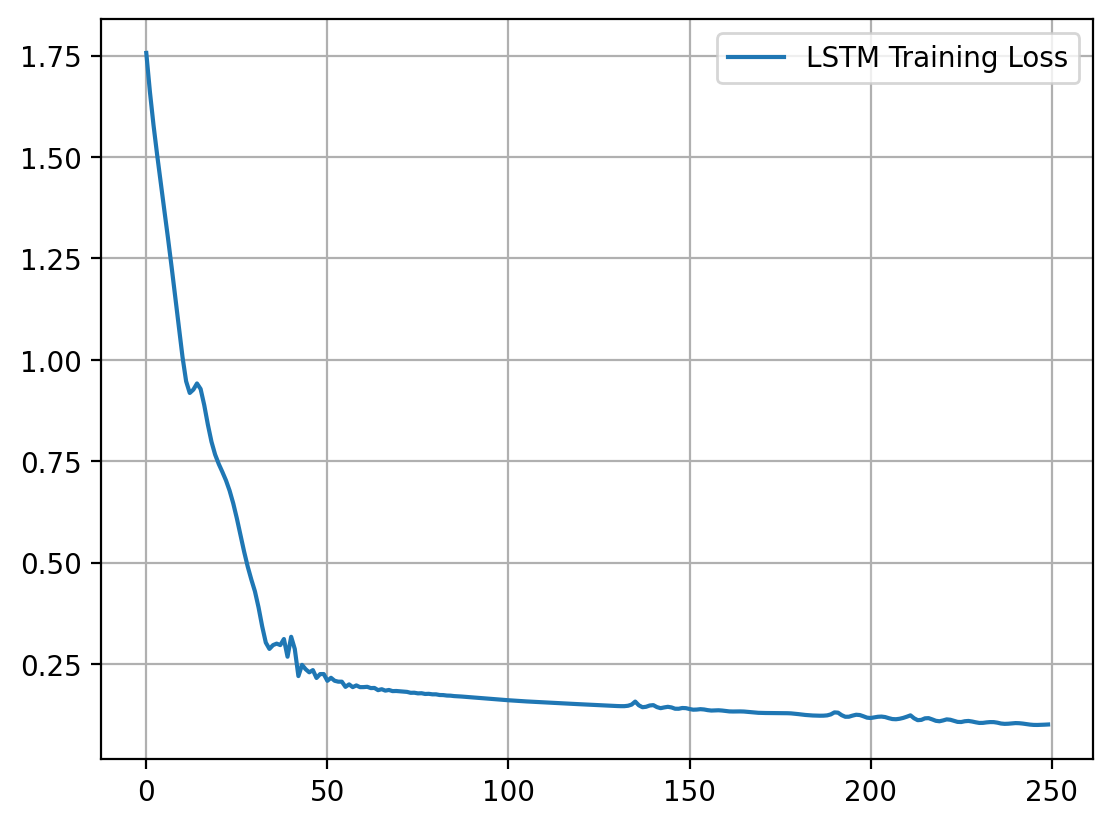

In [20]:
plt.plot(my_lstm.loss_during_training,label='LSTM Training Loss')
plt.grid()
plt.legend()


## Part III-B. One-step-ahead Evaluation of the LSTM

Before using the LSTM for long-horizon autoregressive forecasting, we first examine how well it performs in the **one-step-ahead prediction** setting.

In this experiment, the LSTM receives the first $T_{\text{test}}$ points of each test sequence:

$$
x_0, x_1, \dots, x_{t-1},
$$

and at every time step it predicts the Gaussian parameters $(\mu_t, \sigma_t)$ for the next value $x_t$.

Just as we did for the RNN, we:

1. feed the LSTM the first $T_{\text{test}}$ samples of each test signal,  
2. compute its predicted means and standard deviations,  
3. visualize the predictions and uncertainty for one test sequence, and  
4. compute the **one-step-ahead mean squared error (MSE)**:

$$
\text{MSE} =
\frac{1}{N_{\text{test}}\, T_{\text{test}}}
\sum_{n=1}^{N_{\text{test}}}
\sum_{t=1}^{T_{\text{test}}}
\left( \mu_t^{(n)} - x_t^{(n)} \right)^2.
$$

This metric captures how well the LSTM performs when each prediction is conditioned on the **true** previous value (teacher forcing).  
It therefore evaluates short-term prediction accuracy, without the compounding errors typical of autoregressive forecasting.

In the next block, we run this evaluation and compare the LSTM’s performance to that of the RNN.


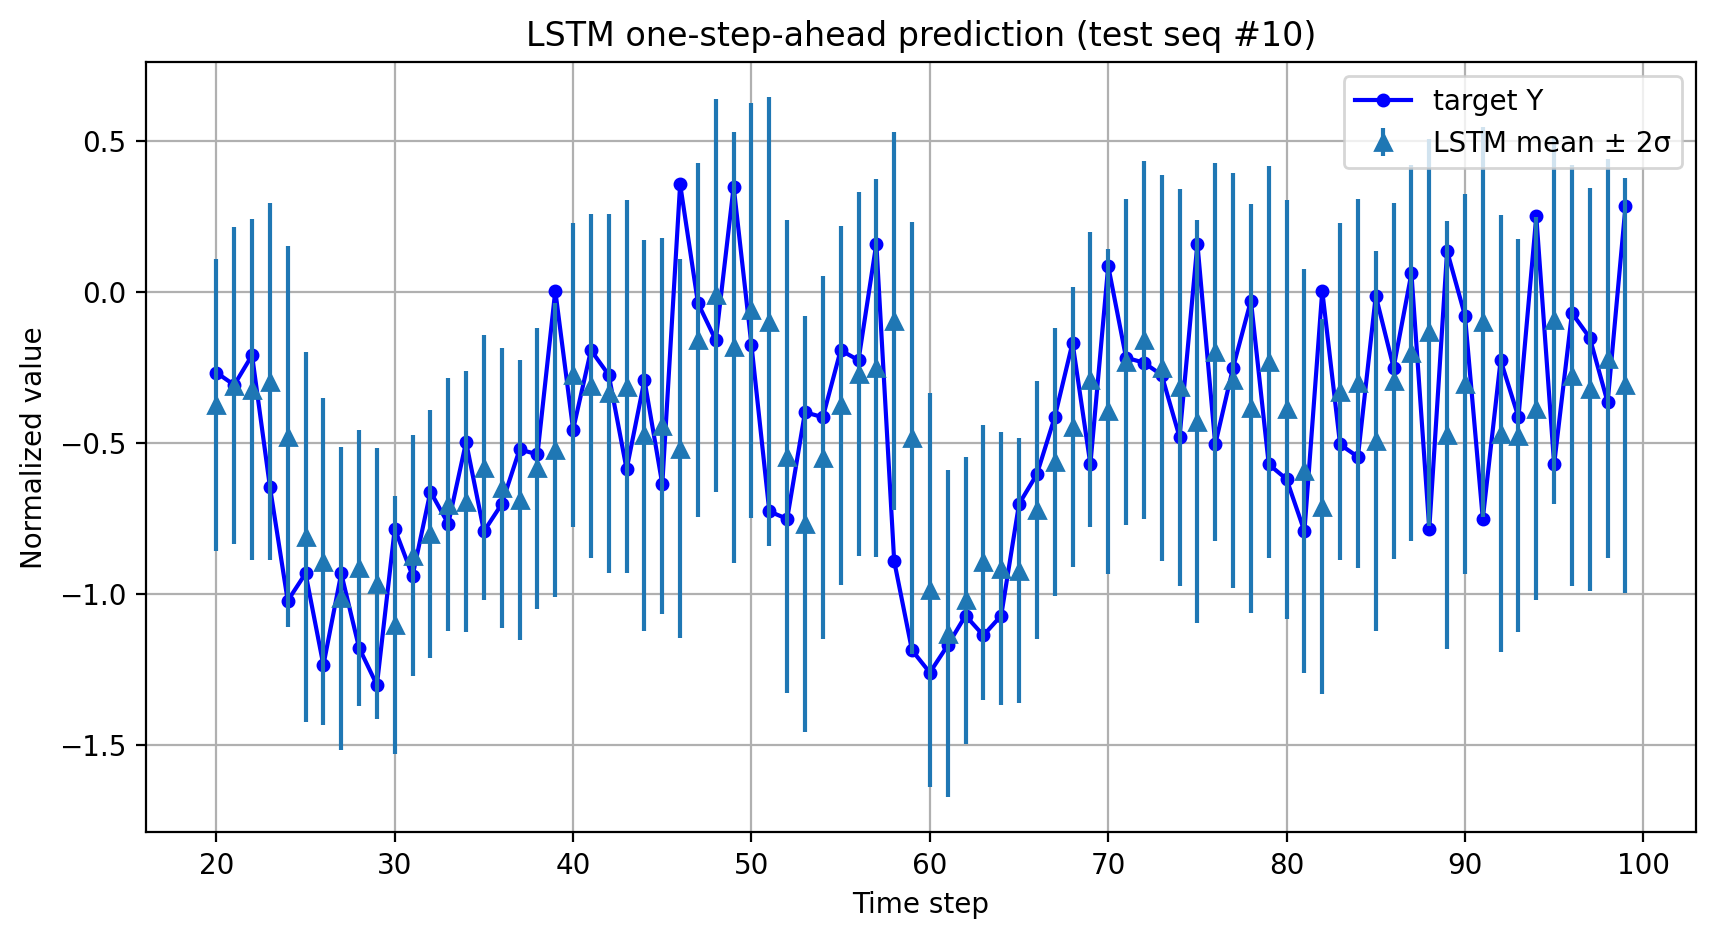

Test one-step-ahead LSTM MSE: 0.079553


In [21]:
# --------------------------------------------------------
# 1. One-step-ahead evaluation for the LSTM model
# --------------------------------------------------------

# Prepare input tensor: take first T_test points and add feature dimension
# X_test: (N_test, T)
# X_in  : (N_test, T_test, 1)
X_in = torch.from_numpy(X_test[:, :T_test]).float().view(N_test, T_test, 1)

# Move model and data to CPU for evaluation
my_lstm.device = torch.device("cpu")
my_lstm.to(my_lstm.device)
X_in = X_in.to(my_lstm.device)

# Run LSTM forward pass (no gradient needed)
with torch.no_grad():
    # mean, std: (N_test, T_test, 1)
    # h: (n_layers, N_test, hidden_dim), c: idem
    mean, std, h, sample = my_lstm.forward(X_in, valid=True)

# Convert predictions to NumPy for plotting and evaluation
mean_lstm = mean.detach().cpu().numpy().reshape(N_test, -1)   # (N_test, T_test)
std_lstm  = std.detach().cpu().numpy().reshape(N_test, -1)    # (N_test, T_test)

# --------------------------------------------------------
# 2. Plot a test sequence with mean ± 2σ error bars
# --------------------------------------------------------

t0 = 20      # start of plot
tf = T_test  # end of plot
signal = 10  # choose a test sequence to display

plt.figure(figsize=(10, 5))

# Ground-truth target
plt.plot(
    np.arange(t0, tf),
    Y_test[signal, t0:tf],
    'b.-',
    ms=8,
    label='target Y'
)

# LSTM predicted mean with uncertainty band
plt.errorbar(
    np.arange(t0, tf),
    mean_lstm[signal, t0:tf],
    2 * std_lstm[signal, t0:tf],
    linestyle='None',
    marker='^',
    label='LSTM mean ± 2σ'
)

plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.title(f"LSTM one-step-ahead prediction (test seq #{signal})")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# --------------------------------------------------------
# 3. Compute global one-step-ahead MSE over the test set
# --------------------------------------------------------
mse_test_lstm = np.mean((mean_lstm - Y_test[:, :T_test]) ** 2)
print(f"Test one-step-ahead LSTM MSE: {mse_test_lstm:.6f}")


## Part III-C. Autoregressive Forecasting with the LSTM

After evaluating the LSTM in the one-step-ahead setting, we now test its ability to
perform **long-horizon autoregressive forecasting**.

In this setting, the LSTM does **not** receive the true next value at each step.
Instead, it must rely entirely on its own predictions to generate the future:

1. We first feed the model the initial $T_{\text{test}}$ points of each test sequence  
   (the same context window used for one-step-ahead evaluation).

2. From this window, the LSTM produces:
   - its predicted means and standard deviations for each step,
   - a sampled trajectory $\hat{x}_0, \dots, \hat{x}_{T_{\text{test}}-1}$,
   - the final hidden and cell state $(h_{T_{\text{test}}}, c_{T_{\text{test}}})$.

3. Starting from the last sampled value and the final LSTM state, we roll the model forward:
   $$
   \hat{x}_{t} = \mu_t + \sigma_t \epsilon_t,
   \qquad
   \epsilon_t \sim \mathcal{N}(0,1),
   $$
   and feed $\hat{x}_t$ back into the LSTM to predict $\hat{x}_{t+1}$.

4. This process is repeated


Effective LSTM forecasting horizon: 20 steps


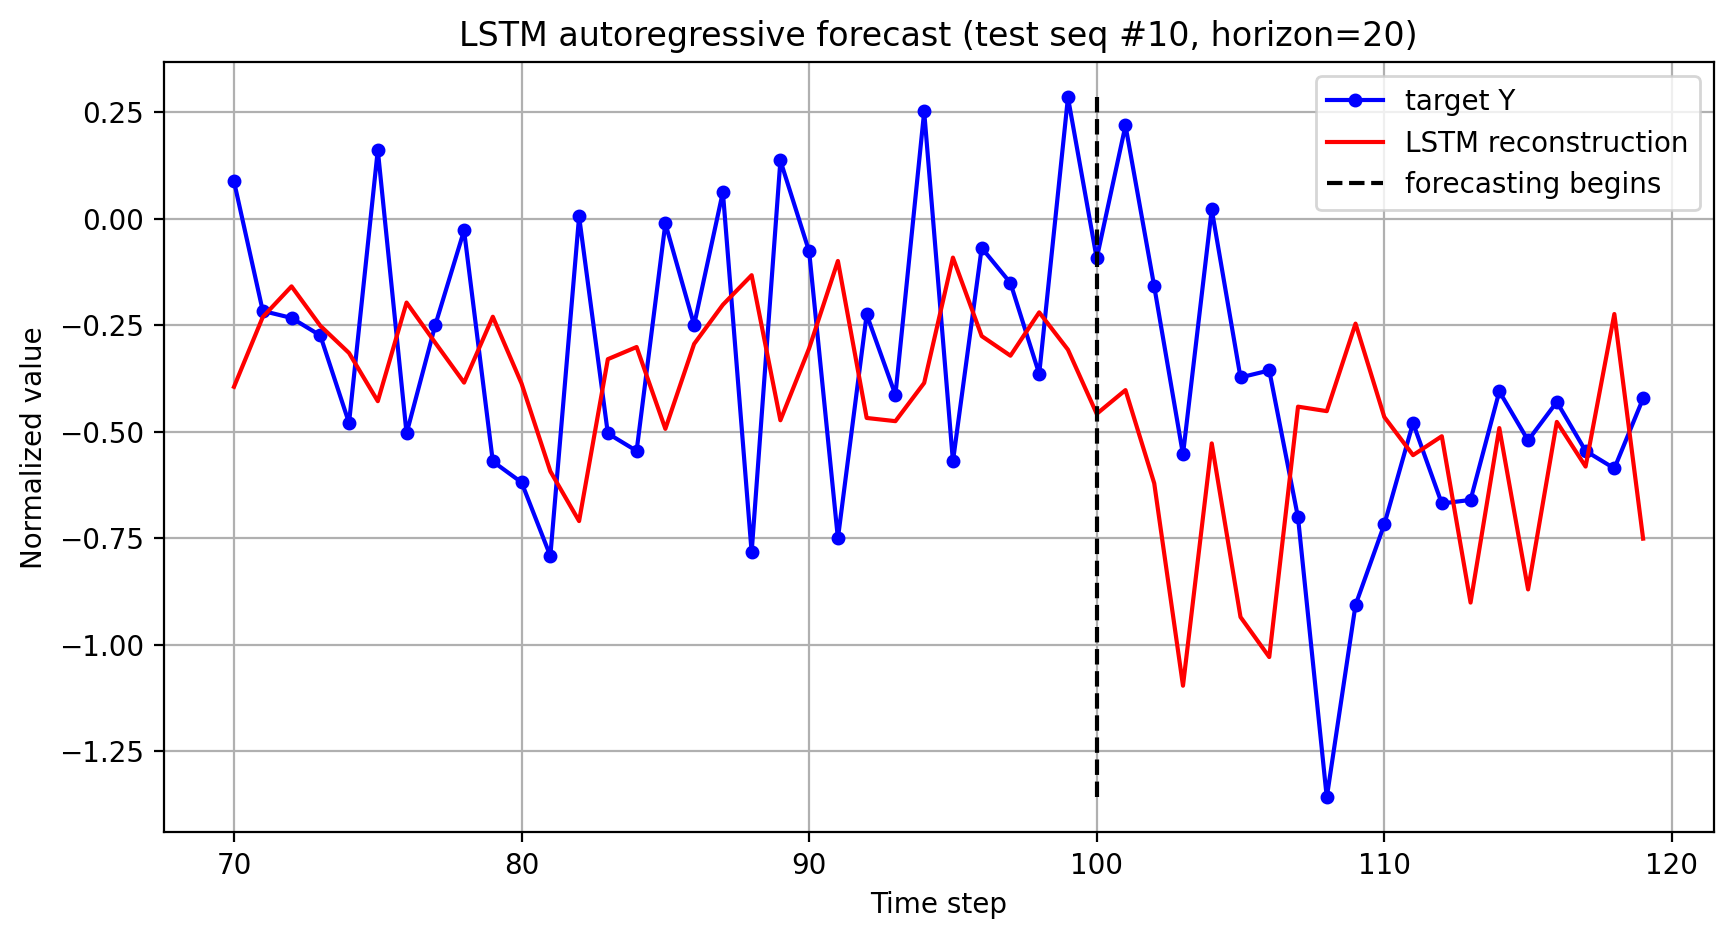

Test forecasting MSE (LSTM, T_test → T_test + 20): 0.321931


In [22]:
# --------------------------------------------------------
# 0. Set forecasting horizon
# --------------------------------------------------------
H_forecasting = 20  # number of steps to forecast beyond T_test

# Ensure we don't go past the sequence length T
H_eff = min(H_forecasting, T - T_test)
print(f"Effective LSTM forecasting horizon: {H_eff} steps")

# --------------------------------------------------------
# 1. Autoregressive forecasting using the trained LSTM
# --------------------------------------------------------
# At this point we already have:
#   - mean_lstm : one-step-ahead means for first T_test points  (N_test, T_test)
#   - std_lstm  : one-step-ahead stds  for first T_test points  (N_test, T_test)
#   - sample    : sampled outputs for the first T_test steps    (N_test, T_test, 1)
#   - h         : final hidden/cell state tuple from the LSTM   ((n_layers, N_test, H), (n_layers, N_test, H))
#
# We now roll the LSTM forward without ground truth, generating the
# next H_eff time steps autoregressively.

# Extract the last sampled value at t = T_test - 1 for each sequence
# sample shape: (N_test, T_test, 1)
current_input = sample[:, -1, :].view(N_test, 1, 1)   # (N_test, 1, 1)

# Last LSTM hidden state (a tuple: (h_T, c_T))
current_state = h  # must already be (h_T, c_T)

# Buffer to store autoregressive forecasts beyond T_test, up to horizon H_eff
forecast_lstm = np.zeros((N_test, H_eff))

# Switch model to eval mode and disable gradients during forecasting
my_lstm.eval()

for t in range(H_eff):
    # Forward one autoregressive step:
    #   - input: last predicted sample  (N_test, 1, 1)
    #   - state: updated LSTM state     (tuple: (h, c))
    #   - outputs: new mean, std, next (h,c), and a new sampled next input
    with torch.no_grad():
        mean_step, std_step, current_state, current_input = my_lstm.forward(
            current_input, current_state, valid=True
        )

    # current_input shape: (N_test, 1, 1) → flatten to (N_test,)
    forecast_lstm[:, t] = current_input.detach().cpu().numpy().reshape(-1)

# --------------------------------------------------------
# 2. Concatenate context window + autoregressive forecast
# --------------------------------------------------------
# final_lstm_reconstruct shape: (N_test, T_test + H_eff)
final_lstm_reconstruct = np.hstack([mean_lstm, forecast_lstm])

# --------------------------------------------------------
# 3. Plot true vs reconstructed trajectory for one test sequence
# --------------------------------------------------------
signal = 10  # index of the test sequence to visualize

# Show some context before T_test and up to the last forecast
t0 = max(0, T_test - 30)
tfinal = T_test + H_eff

plt.figure(figsize=(10, 5))

# Ground truth
plt.plot(
    np.arange(t0, tfinal),
    Y_test[signal, t0:tfinal],
    'b.-',
    ms=8,
    label='target Y'
)

# LSTM reconstruction
plt.plot(
    np.arange(t0, tfinal),
    final_lstm_reconstruct[signal, t0:tfinal],
    'r-',
    label='LSTM reconstruction'
)

# Vertical line marking the point where autoregression begins
plt.plot(
    [T_test, T_test],
    [np.min(Y_test[signal, t0:tfinal]), np.max(Y_test[signal, t0:tfinal])],
    'k--',
    label='forecasting begins'
)

plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.title(f"LSTM autoregressive forecast (test seq #{signal}, horizon={H_eff})")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# --------------------------------------------------------
# 4. Forecasting MSE only over the horizon [T_test, T_test + H_eff)
# --------------------------------------------------------
Y_test_horizon = Y_test[:, T_test:T_test + H_eff]        # (N_test, H_eff)

mse_test_lstm_for = np.mean((forecast_lstm - Y_test_horizon) ** 2)
print(f"Test forecasting MSE (LSTM, T_test → T_test + {H_eff}): {mse_test_lstm_for:.6f}")


## Part IV. A Hybrid LSTM–Transformer Architecture

Recurrent networks such as RNNs and LSTMs are well suited for extracting **local temporal patterns** from sequential data.  
Transformers, on the other hand, are extremely powerful at modeling **global, long-range dependencies** thanks to their multi-head self-attention mechanism.

In this section, we combine both ideas into a **hybrid architecture** that leverages the strengths of each component:

1. **LSTM Encoder**  
   The raw time series is first processed by an LSTM.  
   This stage captures short-term dynamics and produces a sequence of hidden states  
   (one per time step).

2. **Linear Projection to Transformer Dimension**  
   The LSTM output dimensionality (hidden size) is projected into the model dimension  
   `d_model` required by the Transformer.

3. **Positional Encoding**  
   Since Transformers have no notion of temporal order on their own,  
   we add sinusoidal positional encodings to the projected sequence.  
   These encodings inject absolute time-step information into the model.

4. **Transformer Encoder Layers**  
   A stack of multi-head self-attention layers provides global contextualization:  
   each time step can attend to any other, enabling the model to capture  
   dependencies that may span dozens or hundreds of lags.

5. **Gaussian Output Head**  
   Each contextual embedding is fed through a small MLP that predicts  
   the parameters of a Gaussian distribution  
   (mean and standard deviation).  
   A sample is then drawn from this distribution to obtain the next-step prediction.

This architecture is particularly effective for the ETTh1 dataset, where the temporal structure exhibits periodicity and long-range patterns that LSTMs alone may struggle to capture.  
The code below implements this complete LSTM–Transformer pipeline.


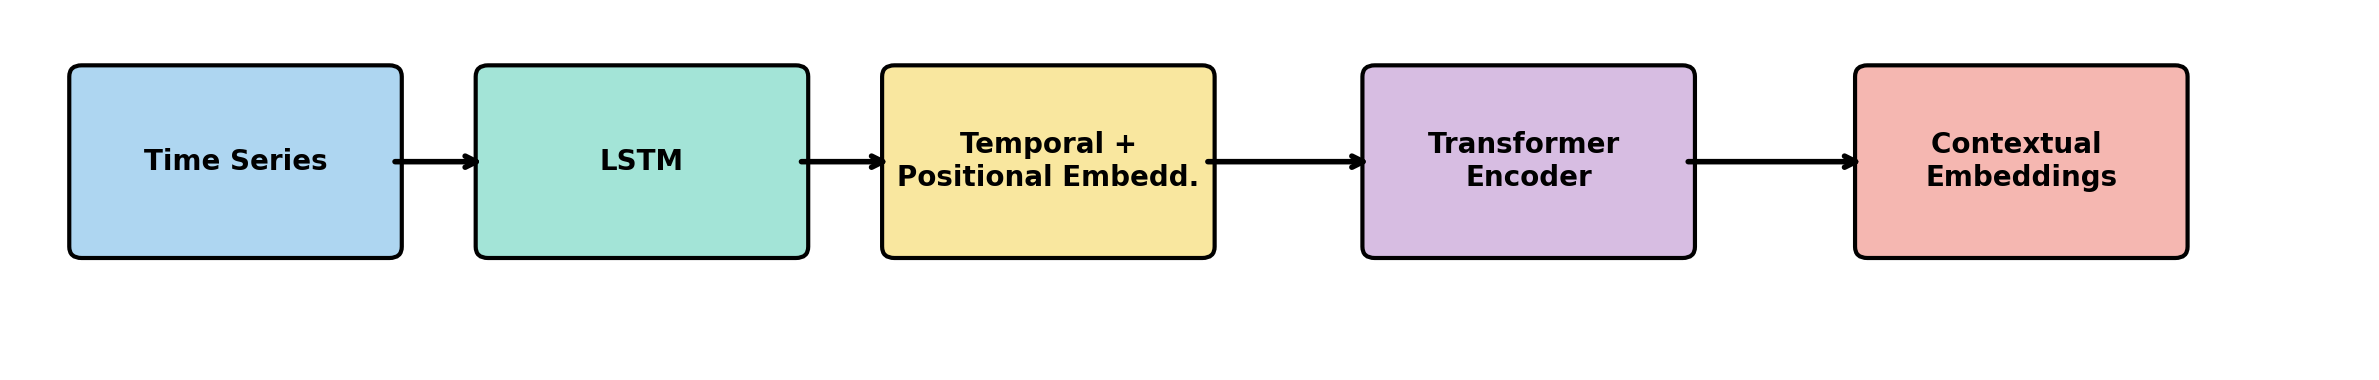

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ------------------------------------------------------------
# Create a horizontal schematic diagram showing the flow:
# Time Series → LSTM → Temporal+Positional Embedding → Transformer → Contextual Embeddings
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 2))

# Blocks to draw: (Label, Color)
blocks = [
    ("Time Series", "#AED6F1"),
    ("LSTM", "#A3E4D7"),
    ("Temporal +\nPositional Embedd.", "#F9E79F"),
    ("Transformer \nEncoder", "#D7BDE2"),
    ("Contextual \nEmbeddings", "#F5B7B1")
]

# Horizontal positions for each block
positions = [-0.5, 2.8, 6.1, 10.0, 14.0]

# ------------------------------------------------------------
# Draw colored rectangles with labels
# ------------------------------------------------------------
for (label, color), x in zip(blocks, positions):
    # Draw a rounded rectangle block
    rect = patches.FancyBboxPatch(
        (x, 0),                # bottom-left corner
        2.5, 1.5,              # width, height
        boxstyle="round,pad=0.1",
        linewidth=1.5,
        edgecolor='black',
        facecolor=color
    )
    ax.add_patch(rect)

    # Add centered text inside the block
    ax.text(
        x + 1.25,              # horizontal center
        0.75,                  # vertical center
        label,
        ha='center',
        va='center',
        fontsize=10,
        weight='bold'
    )

# ------------------------------------------------------------
# Draw arrows connecting the blocks
# ------------------------------------------------------------
for i in range(len(positions) - 1):
    ax.annotate(
        '',                                # no text, just arrow
        xy=(positions[i+1], 0.75),         # arrow end
        xytext=(positions[i] + 2.5, 0.75), # arrow start (right edge of block i)
        arrowprops=dict(arrowstyle='->', lw=2, color='black')
    )

# ------------------------------------------------------------
# Final figure formatting
# ------------------------------------------------------------
ax.set_xlim(-1, 18)
ax.set_ylim(-1, 2)
ax.axis('off')        # remove axes for a clean look

plt.tight_layout()
plt.show()


In [24]:
import math
import torch
import torch.nn as nn

# ------------------------------------------------------------
# Positional Encoding (classic sinusoidal encoding)
# ------------------------------------------------------------
class PositionalEncoding(nn.Module):
    """
    Injects sinusoidal positional information into the sequence embeddings.

    Given an embedding dimension d_model and sequence length T,
    generates the classic Transformer positional encodings:

        PE[pos, 2i]   = sin(pos / 10000^(2i / d_model))
        PE[pos, 2i+1] = cos(pos / 10000^(2i / d_model))

    The buffer 'pe' has shape (1, max_len, d_model).
    """

    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # Create empty positional encoding matrix
        pe = torch.zeros(max_len, d_model)        # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)  # (max_len, 1)

        # Frequency term
        div_term = torch.exp(
            -math.log(10000.0) * torch.arange(0, d_model, 2).float() / d_model
        )

        # Fill even and odd dimensions
        pe[:, 0::2] = torch.sin(position * div_term)   # even dims
        pe[:, 1::2] = torch.cos(position * div_term)   # odd dims

        # Add batch dimension → (1, max_len, d_model)
        pe = pe.unsqueeze(0)

        # register_buffer() ensures the tensor is moved with the model,
        # but is not considered a trainable parameter
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        Returns x + positional encoding for the given sequence length.
        """
        return x + self.pe[:, :x.size(1)]
    

# ------------------------------------------------------------
# LSTM + Transformer Encoder model
# ------------------------------------------------------------
class LSTMTransformer(nn.Module):
    """
    Hybrid architecture combining:
        1. LSTM encoder (local, sequential processing)
        2. Linear projection to d_model
        3. Sinusoidal positional encodings
        4. Transformer Encoder layers (global context)
        5. Gaussian output head (mean + std)
    """

    def __init__(self, input_size=1, hidden_size=32, lstm_layers=1,
                 d_model=16, nhead=4, num_layers=2, dim_feedforward=128,
                 dropout=0.1, output_size=2, max_seq_len=150, sigma=1.0):

        super().__init__()

        # -------------------------
        # LSTM backbone
        # -------------------------
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Project LSTM outputs (hidden_size) → Transformer dimension (d_model)
        self.embedding_proj = nn.Linear(hidden_size, d_model)

        # Positional encoder
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_seq_len)

        # Model dimensions
        self.hidden_dim  = d_model    # used later after Transformer
        self.output_size = output_size
        self.sigma       = sigma      # optional base std (currently unused)

        # -------------------------
        # Transformer Encoder
        # -------------------------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # -------------------------
        # Output MLP (d_model → d_model → [mean, std_raw])
        # -------------------------
        self.fc0  = nn.Linear(d_model, d_model)
        self.relu = nn.ReLU()
        self.fc1  = nn.Linear(d_model, output_size)

        # -------------------------
        # Device handling
        # -------------------------
        USE_GPU = True
        self.device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")
        self.to(self.device)

    # ------------------------------------------------------------
    # Forward pass: x → LSTM → Projection → PositionalEncoding → Transformer
    # ------------------------------------------------------------
    def forward(self, x):
        """
        x: (batch_size, seq_len, 1)

        Returns:
            media  : predicted means      (N, T, 1)
            std    : predicted stds       (N, T, 1)
            r_out  : flattened contextual embeddings (N*T, d_model)
            sample : sampled values        (N, T, 1)
        """

        seq_length = x.size(1)  # T
        x = x.to(self.device)

        # -------------------------
        # 1) LSTM encoding
        # -------------------------
        lstm_out, _ = self.lstm(x)   # (N, T, hidden_size)

        # -------------------------
        # 2) Linear projection → d_model
        # -------------------------
        x = self.embedding_proj(lstm_out)  # (N, T, d_model)

        # -------------------------
        # 3) Add positional encodings
        # -------------------------
        x = self.pos_encoder(x)

        # -------------------------
        # 4) Transformer encoder
        # -------------------------
        # r_out: (N, T, d_model)
        r_out = self.transformer_encoder(x)

        # Flatten for MLP: (N*T, d_model)
        r_out_flat = r_out.reshape(-1, self.hidden_dim)

        # -------------------------
        # 5) Gaussian output head
        # -------------------------
        aux = self.fc1(self.relu(self.fc0(r_out_flat)))

        # Means
        media = aux[:, 0]

        # Standard deviation (positive via softplus)
        std = torch.nn.functional.softplus(aux[:, 1])

        # Sample from N(mean, std^2)
        noise = torch.randn_like(media) * std
        sample = media + noise

        # -------------------------
        # 6) Reshape outputs back to (N, T, 1)
        # -------------------------
        media  = media.reshape(-1, seq_length, 1)
        std    = std.reshape(-1, seq_length, 1)
        sample = sample.reshape(-1, seq_length, 1)

        return media, std, r_out_flat, sample


In [26]:
my_transformer = LSTMTransformer(d_model=16,nhead=1, num_layers=4, dim_feedforward=16,
                                 input_size=1, hidden_size=16, lstm_layers=1,
                                 output_size=2, max_seq_len=T_train, sigma=0.1)

In [27]:
class TR_extended(LSTMTransformer):
    """
    Training wrapper around the LSTMTransformer model.

    Training objective:
        - sample x_hat ~ N(mean, std^2)
        - minimize L2(x_hat, x_true)
    """

    def __init__(self, num_data_train=50, num_iter=200, sequence_length=50,
                 input_size=1, hidden_size=32, lstm_layers=1,
                 d_model=16, nhead=4, num_layers=3, dim_feedforward=32,
                 dropout=0.1, output_size=2, max_seq_len=150,
                 sigma=1.0, drop_prob=0.3, lr=0.005):

        super().__init__(
            input_size=input_size,
            hidden_size=hidden_size,
            lstm_layers=lstm_layers,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            output_size=output_size,
            max_seq_len=max_seq_len,
            sigma=sigma
        )

        self.sequence_length = sequence_length   # T_train
        self.num_train = num_data_train         # N_train
        self.lr = lr
        self.num_iter = num_iter

        self.optim = optim.Adam(self.parameters(), lr=self.lr)
        self.loss_during_training = []

    def trainloop(self, x, y):
        """
        Full-batch training with sampling + L2 loss.

        x : (N_train, T_train)
        y : (N_train, T_train)
        """

        # Pack and move to device ONCE
        x = torch.tensor(x, dtype=torch.float32).view(
            self.num_train, self.sequence_length, 1
        ).to(self.device)

        y = torch.tensor(y, dtype=torch.float32).view(
            self.num_train, self.sequence_length, 1
        ).to(self.device)

        for e in range(int(self.num_iter)):

            self.optim.zero_grad()

            # Forward → mean, std, contextual embeddings, and *sampled* trajectory
            mean, std, hid, sample = self.forward(x)

            # L2 loss between sampled prediction and ground truth
            loss = torch.mean((sample - y) ** 2)

            loss.backward()

            # Gradient clipping
            nn.utils.clip_grad_norm_(self.parameters(), max_norm=2.0)

            self.optim.step()

            self.loss_during_training.append(loss.item())

            if e % 50 == 0:
                print(f"Iteration {e}, Training loss (L2 on samples): {loss.item():.6f}")


In [30]:
class TR_extended(LSTMTransformer):
    """
    Extended Transformer + LSTM model with a simple training loop for
    one-step-ahead forecasting using a Gaussian negative log-likelihood loss.
    """

    def __init__(
        self,
        num_data_train: int = 50,         # Number of training sequences used per epoch
        num_iter: int = 200,              # Number of training iterations (epochs)
        sequence_length: int = 50,        # Length of each input sequence
        input_size: int = 1,              # Input dimension per time step
        hidden_size: int = 32,            # LSTM hidden size
        lstm_layers: int = 1,             # Number of LSTM layers
        d_model: int = 16,                # Transformer model dimension
        nhead: int = 4,                   # Number of attention heads
        num_layers: int = 3,              # Number of Transformer encoder layers
        dim_feedforward: int = 32,        # Feedforward dimension inside Transformer
        dropout: float = 0.1,             # Dropout rate
        output_size: int = 2,             # Output size (mean + std -> 2 * #features)
        max_seq_len: int = 150,           # Max sequence length supported by positional encoding
        sigma: float = 1.0,               # Initial std for sampling (if used)
        drop_prob: float = 0.3,           # (Unused here, but kept for compatibility)
        lr: float = 0.005                 # Learning rate
    ):
        super().__init__(
            input_size=input_size,
            hidden_size=hidden_size,
            lstm_layers=lstm_layers,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            output_size=output_size,
            max_seq_len=max_seq_len,
            sigma=sigma,
        )

        # Store hyperparameters
        self.hidden_dim = d_model
        self.output_size = output_size
        self.sequence_length = sequence_length
        self.lr = lr
        self.num_train = num_data_train
        self.num_iter = num_iter

        # Optimizer
        self.optim = optim.Adam(self.parameters(), lr=self.lr)

        # To store training loss over iterations
        self.loss_during_training = []

    def gaussian_nll(self, y: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
        """
        Gaussian negative log-likelihood (averaged over all elements).

        y    : target values  (N, T, D)
        mean : predicted mean (N, T, D)
        std  : predicted std  (N, T, D), must be positive
        """
        eps = 1e-6  # To avoid log(0) and division by zero
        std = std + eps
        var = std ** 2

        # Element-wise log probability of a Gaussian
        log_prob = -0.5 * (torch.log(2 * torch.pi * var) + ((y - mean) ** 2) / var)

        # Return negative average log-likelihood
        return -log_prob.mean()

    def trainloop(self, x, y):
        """
        Simple SGD/Adam training loop.

        x, y : arrays or tensors of shape (num_train, sequence_length)
               or (num_train, sequence_length, 1). We reshape inside.
        """

        # Convert input data to torch tensors on the correct device once
        # output_size = 2 * (#features). For univariate, #features = 1 -> output_size=2.
        num_features = int(self.output_size / 2)

        x_tensor = torch.as_tensor(x, dtype=torch.float32).view(
            self.num_train, self.sequence_length, num_features
        ).to(self.device)

        y_tensor = torch.as_tensor(y, dtype=torch.float32).view(
            self.num_train, self.sequence_length, num_features
        ).to(self.device)

        # Training loop
        for e in range(int(self.num_iter)):
            self.train()            # Ensure model is in training mode
            self.optim.zero_grad()  # Reset gradients

            # Forward pass
            mean, std, hidden, out = self.forward(x_tensor)

            # Compute Gaussian NLL loss
            loss = self.gaussian_nll(y_tensor, mean, std)

            # Backward pass
            loss.backward()

            # Gradient clipping to stabilize training
            nn.utils.clip_grad_norm_(self.parameters(), max_norm=2.0)

            # Parameter update
            self.optim.step()

            # Store scalar loss (no need to divide by num_iter)
            self.loss_during_training.append(loss.item())

            # Print progress every 50 iterations
            if e % 50 == 0:
                print(f"Iteration {e:4d} - Training loss: {self.loss_during_training[-1]:.6f}")


In [31]:
my_TF= TR_extended(d_model=64, num_layers=2, nhead = 4, dim_feedforward=16, hidden_size=32, num_data_train=X_train.shape[0],num_iter=250,sequence_length=T_train,lr=0.005,sigma=0.5)

In [32]:
my_TF.trainloop(X_train[:,:T_train],Y_train[:,:T_train])

Iteration    0 - Training loss: 1.881302
Iteration   50 - Training loss: 0.411149
Iteration  100 - Training loss: 0.185887
Iteration  150 - Training loss: -0.012438
Iteration  200 - Training loss: -0.468759


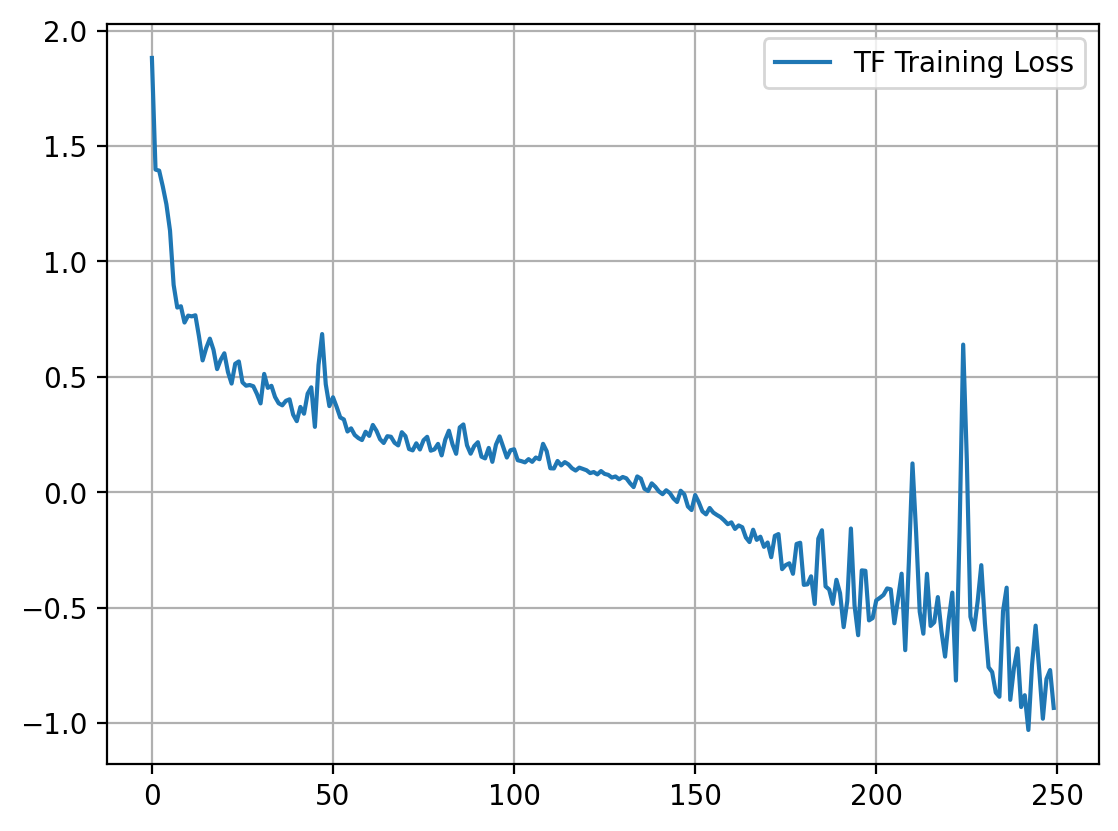

In [33]:
plt.plot(my_TF.loss_during_training,label='TF Training Loss')
plt.grid()
plt.legend()


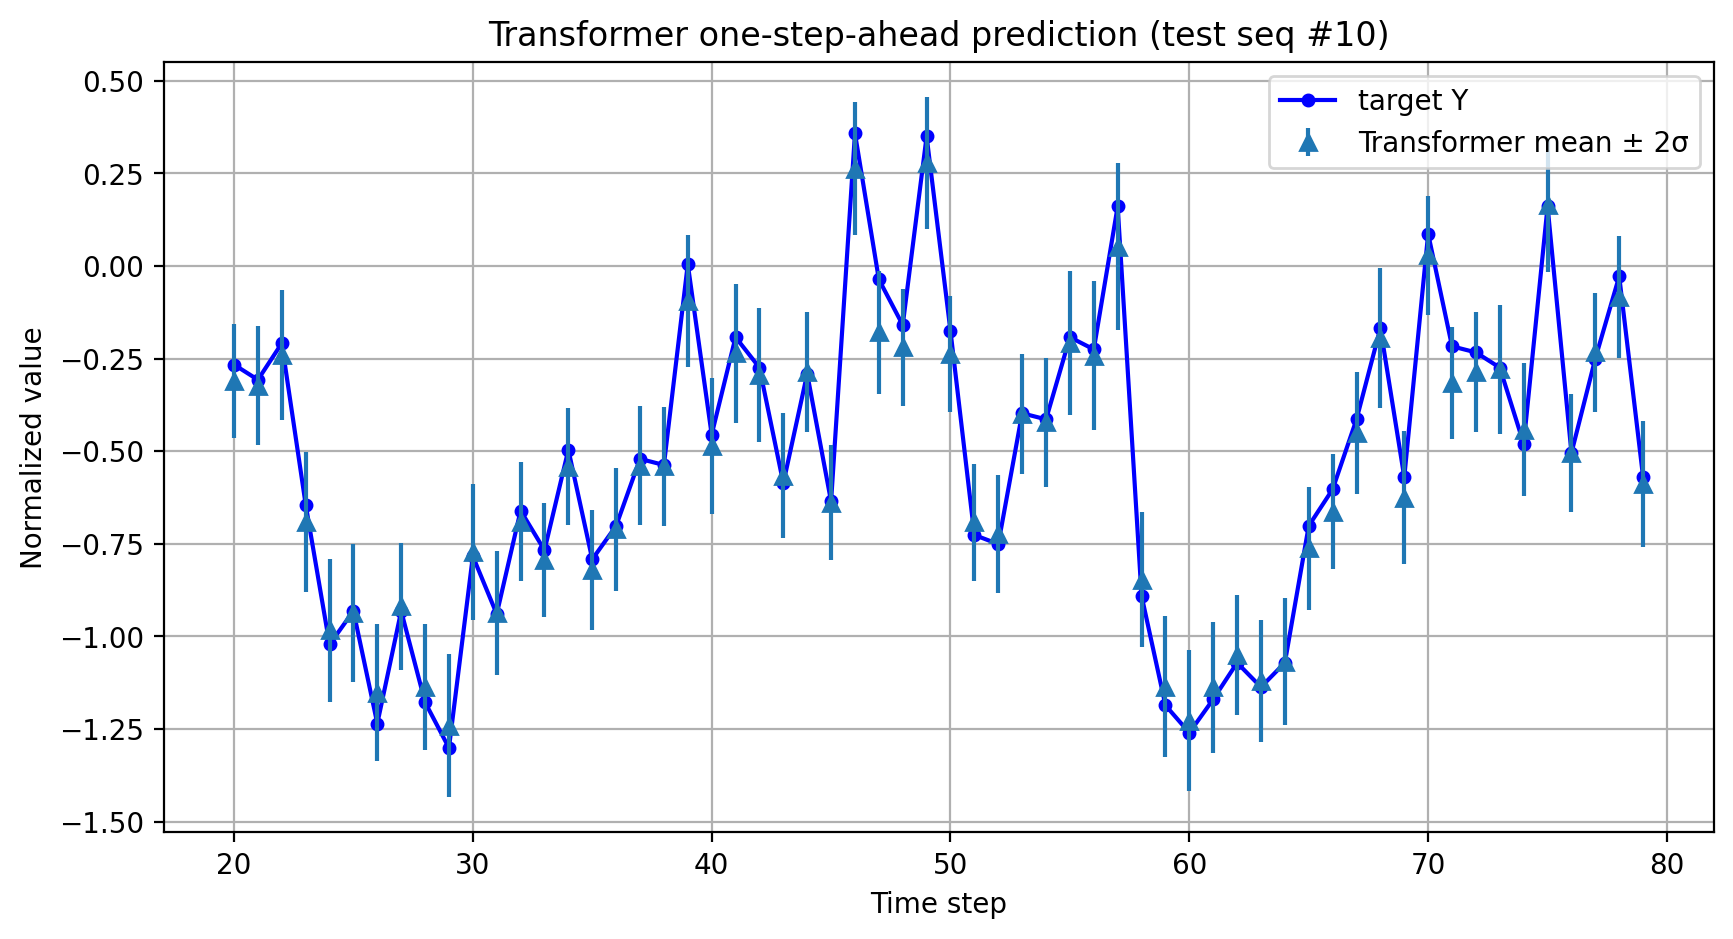

Test one-step-ahead Transformer MSE: 0.006444


In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 1. One-step-ahead evaluation for the Transformer model
# --------------------------------------------------------

# Move model to CPU and set evaluation mode
my_TF.device = torch.device("cpu")
my_TF.to(my_TF.device)
my_TF.eval()

# Build input tensor:
#   X_test: (N_test, T)
#   X_in  : (N_test, T_test, 1)
X_in = torch.from_numpy(X_test[:, :T_test]).float().view(N_test, T_test, 1).to(my_TF.device)

# Forward pass (no gradients)
with torch.no_grad():
    # mean, std: (N_test, T_test, 1)
    # h: contextual embeddings (flattened), sample: (N_test, T_test, 1)
    mean, std, h, sample = my_TF.forward(X_in)

# Convert predictions to NumPy for visualization and metrics
mean_TF = mean.detach().cpu().numpy().reshape(N_test, -1)  # (N_test, T_test)
std_TF  = std.detach().cpu().numpy().reshape(N_test, -1)   # (N_test, T_test)

# --------------------------------------------------------
# 2. Plot an example test sequence with mean ± 2σ
# --------------------------------------------------------

t0 = 20    # initial time for the plot
tf = 80    # final time (exclusive)
signal = 10  # choose a test sequence index

plt.figure(figsize=(10, 5))

# Ground-truth target
plt.plot(
    np.arange(t0, tf),
    Y_test[signal, t0:tf],
    'b.-',
    ms=8,
    label='target Y'
)

# Transformer predicted mean with uncertainty band
plt.errorbar(
    np.arange(t0, tf),
    mean_TF[signal, t0:tf],
    2 * std_TF[signal, t0:tf],
    linestyle='None',
    marker='^',
    label='Transformer mean ± 2σ'
)

plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.title(f"Transformer one-step-ahead prediction (test seq #{signal})")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# --------------------------------------------------------
# 3. Compute global one-step-ahead MSE over the test set
# --------------------------------------------------------
mse_test_TF = np.mean((mean_TF - Y_test[:, :T_test]) ** 2)
print(f"Test one-step-ahead Transformer MSE: {mse_test_TF:.6f}")


Test one-step-ahead Transformer MSE (up to T_test): 0.006444
Effective Transformer forecasting horizon: 20 steps


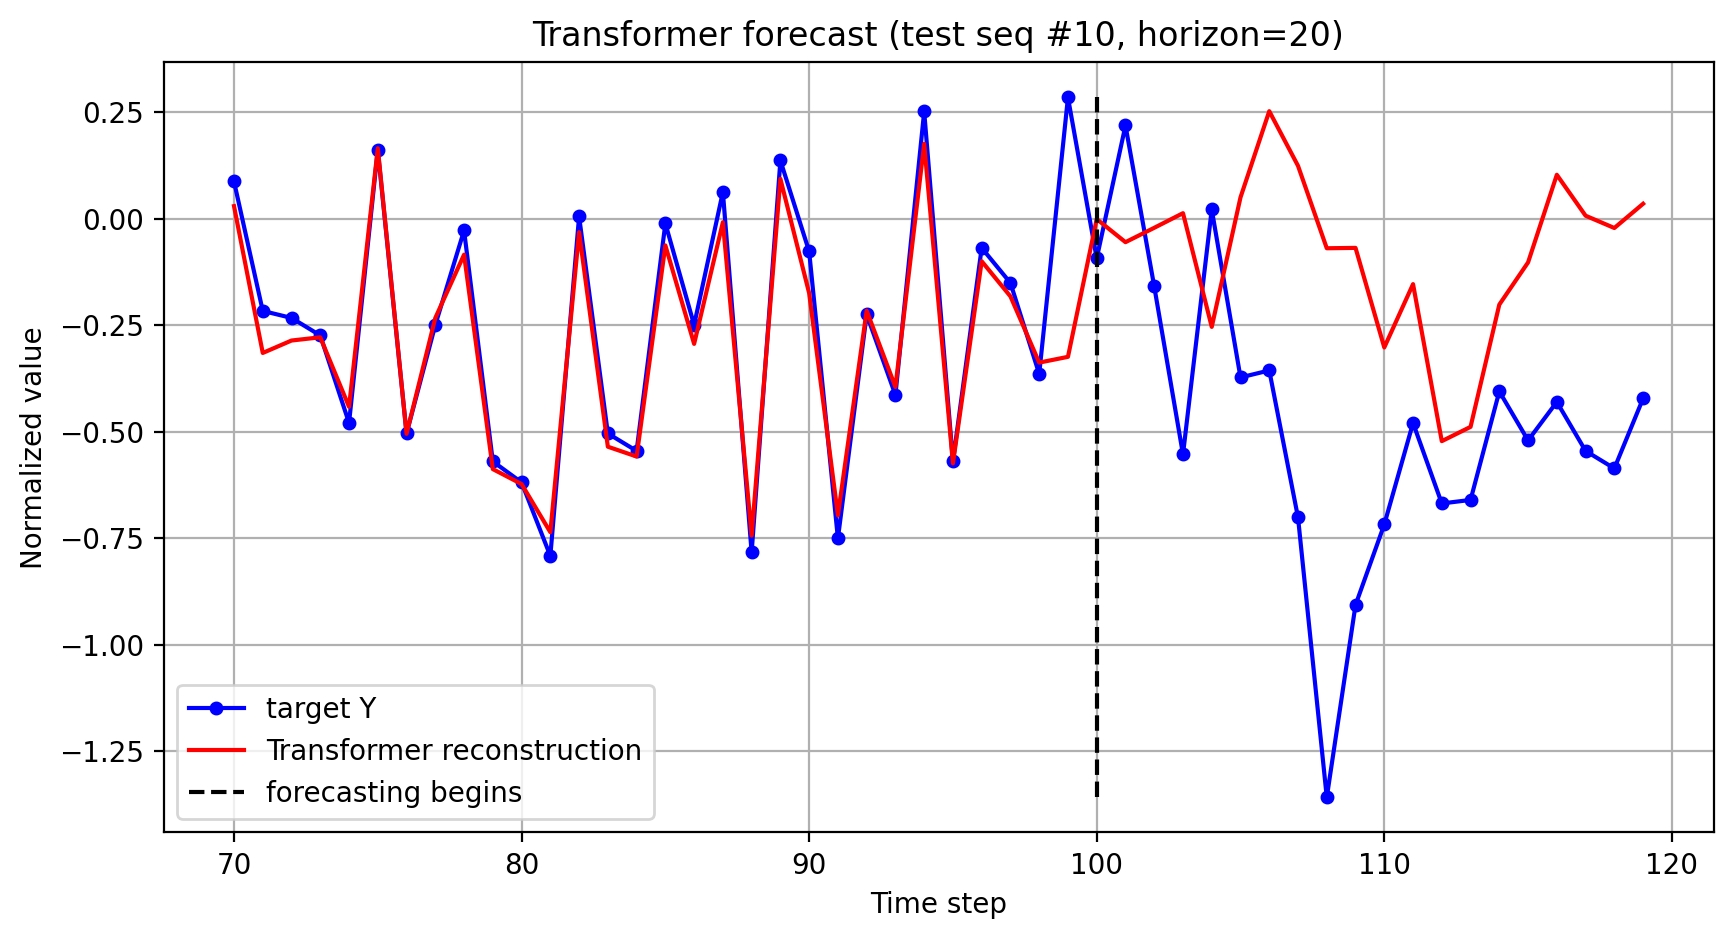

Test forecasting MSE (Transformer, T_test → T_test + 20): 0.358934


In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 0. One-step-ahead evaluation for the Transformer model
# --------------------------------------------------------

# Move model to CPU and set evaluation mode
my_TF.device = torch.device("cpu")
my_TF.to(my_TF.device)
my_TF.eval()

# Build input tensor for context window:
#   X_test: (N_test, T)
#   X_in  : (N_test, T_test, 1)
X_in = torch.from_numpy(X_test[:, :T_test]).float().view(N_test, T_test, 1).to(my_TF.device)

# Forward pass (no gradients) over the context window
with torch.no_grad():
    # mean, std: (N_test, T_test, 1)
    # h: contextual embeddings (unused here)
    # sample: (N_test, T_test, 1) sampled trajectory for the context
    mean, std, h, sample = my_TF.forward(X_in)

# Convert predictions to NumPy for visualization and metrics
mean_TF = mean.detach().cpu().numpy().reshape(N_test, -1)  # (N_test, T_test)
std_TF  = std.detach().cpu().numpy().reshape(N_test, -1)   # (N_test, T_test)

# --------------------------------------------------------
# 1. One-step-ahead MSE over the test set (context part)
# --------------------------------------------------------
mse_test_TF = np.mean((mean_TF - Y_test[:, :T_test]) ** 2)
print(f"Test one-step-ahead Transformer MSE (up to T_test): {mse_test_TF:.6f}")

# --------------------------------------------------------
# 2. Fixed-horizon autoregressive forecasting from T_test
# --------------------------------------------------------

H_forecasting = 20  # number of steps to forecast beyond T_test
H_eff = min(H_forecasting, T - T_test)
print(f"Effective Transformer forecasting horizon: {H_eff} steps")

# Start autoregression from the last context window
# current_signal: (N_test, T_test, 1)
current_signal = X_in.clone()

# Buffer for autoregressive forecast: (N_test, H_eff)
forecast_TF = np.zeros((N_test, H_eff))

for t in range(H_eff):
    # At each step, the Transformer sees the full current window
    # and we use the last output as the next input.
    with torch.no_grad():
        mean_step, std_step, h_step, output = my_TF.forward(current_signal)

    # output: (N_test, T_test, 1); take last time step as new value
    new_value = output[:, -1, 0].detach().cpu().numpy()  # (N_test,)
    forecast_TF[:, t] = new_value

    # Build next input window by dropping the first step and appending the new one
    new_input = output[:, -1, :].unsqueeze(1)            # (N_test, 1, 1)
    current_signal = torch.cat([current_signal[:, 1:, :], new_input], dim=1)

# Reconstruction up to T_test + H_eff: context means + forecasts
final_TF_reconstruct = np.hstack([mean_TF, forecast_TF])  # (N_test, T_test + H_eff)

# --------------------------------------------------------
# 3. Plot example test sequence: context + forecast horizon
# --------------------------------------------------------
signal = 10  # index of the test sequence to visualize
t0 = max(0, T_test - 30)
tfinal = T_test + H_eff

plt.figure(figsize=(10, 5))

# Ground truth
plt.plot(
    np.arange(t0, tfinal),
    Y_test[signal, t0:tfinal],
    'b.-',
    ms=8,
    label='target Y'
)

# Transformer reconstruction
plt.plot(
    np.arange(t0, tfinal),
    final_TF_reconstruct[signal, t0:tfinal],
    'r-',
    label='Transformer reconstruction'
)

# Vertical line at T_test where forecasting starts
plt.plot(
    [T_test, T_test],
    [np.min(Y_test[signal, t0:tfinal]), np.max(Y_test[signal, t0:tfinal])],
    'k--',
    label='forecasting begins'
)

plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.title(f"Transformer forecast (test seq #{signal}, horizon={H_eff})")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# --------------------------------------------------------
# 4. Forecasting MSE only over the horizon [T_test, T_test + H_eff)
# --------------------------------------------------------
Y_test_horizon = Y_test[:, T_test:T_test + H_eff]        # (N_test, H_eff)

mse_test_TF_for = np.mean((forecast_TF - Y_test_horizon) ** 2)
print(f"Test forecasting MSE (Transformer, T_test → T_test + {H_eff}): {mse_test_TF_for:.6f}")


In [38]:
# Clear cache (recommended)
torch.cuda.empty_cache()

# Optional: Collect unused memory (more aggressive)
torch.cuda.ipc_collect()

torch.cuda.synchronize()

In [41]:
metrics = {
    "Model": ["RNN", "LSTM", "Transformer"],
    "One-step MSE": [
        mse_test,
        mse_test_lstm,
        mse_test_TF
    ],
    f"Horizon MSE (H={H_eff})": [
        mse_test_for,
        mse_test_lstm_for,
        mse_test_TF_for
    ]
}


In [42]:

df_metrics = pd.DataFrame(metrics)
df_metrics

,Model,One-step MSE,Horizon MSE (H=20)
0,RNN,0.079916,0.451069
1,LSTM,0.079553,0.321931
2,Transformer,0.006444,0.358934
